In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/deepanjalithakur/boulder-dataset-1/Electric_Vehicle_Charging_Station_Data_-4748264627261459144.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Bidirectional,
                                      Input, Lambda, Concatenate, Layer)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from scipy.spatial.distance import cdist

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [4]:
df = pd.read_csv('/kaggle/input/datasets/deepanjalithakur/boulder-dataset-1/Electric_Vehicle_Charging_Station_Data_-4748264627261459144.csv', low_memory=False)

print("Shape:", df.shape)
print("\nNulls:\n", df.isnull().sum())
print("\nFirst 3 rows:")
df.head(3)

Shape: (148136, 17)

Nulls:
 Station_Name                  0
Address                       0
City                          0
State_Province                0
Zip_Postal_Code               0
Start_Date___Time             0
Start_Time_Zone               0
End_Date___Time               4
End_Time_Zone                 0
Total_Duration__hh_mm_ss_     0
Charging_Time__hh_mm_ss_      0
Energy__kWh_                  0
GHG_Savings__kg_              0
Gasoline_Savings__gallons_    0
Port_Type                     0
ObjectID                      0
ObjectId2                     0
dtype: int64

First 3 rows:


,Station_Name,Address,City,State_Province,Zip_Postal_Code,Start_Date___Time,Start_Time_Zone,End_Date___Time,End_Time_Zone,Total_Duration__hh_mm_ss_,Charging_Time__hh_mm_ss_,Energy__kWh_,GHG_Savings__kg_,Gasoline_Savings__gallons_,Port_Type,ObjectID,ObjectId2
0,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/1/2018 17:49,MDT,1/1/2018 19:52,MDT,2:03:02,2:02:44,6.504,2.732,0.816,Level 2,0,1
1,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/2/2018 8:52,MDT,1/2/2018 9:16,MDT,0:24:34,0:24:19,2.481,1.042,0.311,Level 2,1,2
2,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/2/2018 21:11,MDT,1/3/2018 6:23,MDT,9:12:21,3:40:52,15.046,6.319,1.888,Level 2,2,3


In [5]:
df['start'] = pd.to_datetime(df['Start_Date___Time'], errors='coerce')
df = df.dropna(subset=['start'])

df['hour'] = df['start'].dt.floor('h')
hourly = df.groupby('hour').agg(
    total_kWh    = ('Energy__kWh_', 'sum'),
    num_sessions = ('Energy__kWh_', 'count')
).reset_index()

full_range = pd.date_range(start=hourly['hour'].min(), end=hourly['hour'].max(), freq='h')
hourly = hourly.set_index('hour').reindex(full_range).reset_index()
hourly.columns = ['datetime', 'total_kWh', 'num_sessions']
hourly['total_kWh']    = hourly['total_kWh'].fillna(0)
hourly['num_sessions'] = hourly['num_sessions'].fillna(0)

# Add time features
hourly['hour_of_day'] = hourly['datetime'].dt.hour
hourly['day_of_week'] = hourly['datetime'].dt.dayofweek
hourly['month']       = hourly['datetime'].dt.month
hourly['is_weekend']  = (hourly['day_of_week'] >= 5).astype(int)

print("Hourly records:", len(hourly))
print(hourly.head())

Hourly records: 51823
             datetime  total_kWh  num_sessions  hour_of_day  day_of_week  \
0 2018-01-01 17:00:00     13.008           2.0           17            0   
1 2018-01-01 18:00:00      0.000           0.0           18            0   
2 2018-01-01 19:00:00      0.000           0.0           19            0   
3 2018-01-01 20:00:00      0.000           0.0           20            0   
4 2018-01-01 21:00:00      0.000           0.0           21            0   

   month  is_weekend  
0      1           0  
1      1           0  
2      1           0  
3      1           0  
4      1           0  


In [6]:
hourly['hour_sin'] = np.sin(2 * np.pi * hourly['hour_of_day'] / 24)
hourly['hour_cos'] = np.cos(2 * np.pi * hourly['hour_of_day'] / 24)
hourly['day_sin']  = np.sin(2 * np.pi * hourly['day_of_week'] / 7)
hourly['day_cos']  = np.cos(2 * np.pi * hourly['day_of_week'] / 7)
hourly['month_sin'] = np.sin(2 * np.pi * hourly['month'] / 12)
hourly['month_cos'] = np.cos(2 * np.pi * hourly['month'] / 12)

# ✅ NEW: Add lag features to capture weekly and daily patterns
hourly['lag_24']  = hourly['total_kWh'].shift(24)   # same hour yesterday
hourly['lag_168'] = hourly['total_kWh'].shift(168)  # same hour last week
hourly['lag_1']   = hourly['total_kWh'].shift(1)    # previous hour

# ✅ NEW: Add session count as input signal
# num_sessions already exists from aggregation step

hourly = hourly.dropna()  # drop NaN rows from lag shift
hourly = hourly.reset_index(drop=True)

features = ['total_kWh', 'num_sessions',
            'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
            'month_sin', 'month_cos', 'is_weekend',
            'lag_1', 'lag_24', 'lag_168']

print(f"Features : {features}")
print(f"Total features : {len(features)}")  # now 12

Features : ['total_kWh', 'num_sessions', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'is_weekend', 'lag_1', 'lag_24', 'lag_168']
Total features : 12


In [8]:
# Split (year-based chronological split)
train = hourly[hourly['datetime'] < '2023-01-01']
val   = hourly[(hourly['datetime'] >= '2023-01-01') & (hourly['datetime'] < '2023-07-01')]
test  = hourly[hourly['datetime'] >= '2023-07-01']

print(f"Train : {len(train):,} hours ({train['datetime'].min().date()} → {train['datetime'].max().date()})")
print(f"Val   : {len(val):,} hours  ({val['datetime'].min().date()} → {val['datetime'].max().date()})")
print(f"Test  : {len(test):,} hours  ({test['datetime'].min().date()} → {test['datetime'].max().date()})")

# Scale — uses the 8-feature list defined in Cell 2
scaler_target = MinMaxScaler()
scaler_all    = MinMaxScaler()

train_s = scaler_all.fit_transform(train[features])
val_s   = scaler_all.transform(val[features])
test_s  = scaler_all.transform(test[features])

scaler_target.fit(train[['total_kWh']])

print(f"\nFeatures used : {features}")
print(f"Train scaled shape : {train_s.shape}")
print("Scaling done ✅")

Train : 43,639 hours (2018-01-08 → 2022-12-31)
Val   : 4,344 hours  (2023-01-01 → 2023-06-30)
Test  : 3,672 hours  (2023-07-01 → 2023-11-30)

Features used : ['total_kWh', 'num_sessions', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'is_weekend', 'lag_1', 'lag_24', 'lag_168']
Train scaled shape : (43639, 12)
Scaling done ✅


In [9]:
# ============================================================
# DATASET STATISTICS TABLE
# ============================================================
total_hours    = len(hourly)
nonzero_hours  = (hourly['total_kWh'] > 0).sum()
zero_hours     = total_hours - nonzero_hours
zero_pct       = zero_hours / total_hours * 100
total_kwh      = hourly['total_kWh'].sum()
avg_kwh_nz     = hourly.loc[hourly['total_kWh'] > 0, 'total_kWh'].mean()
peak_kwh       = hourly['total_kWh'].max()
total_sessions = hourly['num_sessions'].sum()
date_start     = hourly['datetime'].min().date()
date_end       = hourly['datetime'].max().date()
date_range_days= (hourly['datetime'].max() - hourly['datetime'].min()).days

print("=" * 55)
print("         DATASET STATISTICS — BOULDER EV DATASET")
print("=" * 55)
print(f"  Date range         : {date_start} → {date_end}")
print(f"  Total days         : {date_range_days:,}")
print(f"  Total hours        : {total_hours:,}")
print(f"  Non-zero hours     : {nonzero_hours:,}  ({100-zero_pct:.1f}%)")
print(f"  Zero-demand hours  : {zero_hours:,}  ({zero_pct:.1f}%)")
print(f"  Total energy (kWh) : {total_kwh:,.2f}")
print(f"  Avg kWh (non-zero) : {avg_kwh_nz:.2f}")
print(f"  Peak hourly kWh    : {peak_kwh:.2f}")
print(f"  Total sessions     : {int(total_sessions):,}")
print(f"  Input features     : {len(features)}")
print(f"  Lookback window    : 168 hours (7 days)")
print("=" * 55)

# Train/val/test breakdown
print()
print("  Split breakdown:")
print(f"  Train : {len(train):,} hours  ({train['datetime'].min().date()} → {train['datetime'].max().date()})")
print(f"  Val   : {len(val):,} hours   ({val['datetime'].min().date()} → {val['datetime'].max().date()})")
print(f"  Test  : {len(test):,} hours   ({test['datetime'].min().date()} → {test['datetime'].max().date()})")
print("=" * 55)

         DATASET STATISTICS — BOULDER EV DATASET
  Date range         : 2018-01-08 → 2023-11-30
  Total days         : 2,152
  Total hours        : 51,655
  Non-zero hours     : 25,887  (50.1%)
  Zero-demand hours  : 25,768  (49.9%)
  Total energy (kWh) : 1,185,459.25
  Avg kWh (non-zero) : 45.79
  Peak hourly kWh    : 454.12
  Total sessions     : 140,268
  Input features     : 12
  Lookback window    : 168 hours (7 days)

  Split breakdown:
  Train : 43,639 hours  (2018-01-08 → 2022-12-31)
  Val   : 4,344 hours   (2023-01-01 → 2023-06-30)
  Test  : 3,672 hours   (2023-07-01 → 2023-11-30)


In [10]:
LOOKBACK = 168  # ✅ 7 days — captures weekly seasonality

def make_sequences(data, lookback=LOOKBACK):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_s)
X_val,   y_val   = make_sequences(val_s)
X_test,  y_test  = make_sequences(test_s)

print(f"X_train shape : {X_train.shape}")  # should be (samples, 168, 12)
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")

X_train shape : (43471, 168, 12)
X_val shape   : (4176, 168, 12)
X_test shape  : (3504, 168, 12)


In [24]:
import tensorflow as tf
tf.keras.backend.clear_session()

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 12)),  # ✅ 12 features
    Dropout(0.1),
    LSTM(64, return_sequences=False),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='huber')  # ✅ robust to spikes
model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    min_delta=0.00005,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,849 (214.25 KB)

 Trainable params: 54,849 (214.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0033 - val_loss: 0.0070 - learning_rate: 5.0000e-04
Epoch 2/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0023 - val_loss: 0.0068 - learning_rate: 5.0000e-04
Epoch 3/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0023 - val_loss: 0.0062 - learning_rate: 5.0000e-04
Epoch 4/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0021 - val_loss: 0.0058 - learning_rate: 5.0000e-04
Epoch 5/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0022 - val_loss: 0.0060 - learning_rate: 5.0000e-04
Epoch 6/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0021 - val_loss: 0.0058 - learning_rate: 5.0000e-04
Epoch 7/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0021 - val_loss: 0.0059 - learning_rate: 5.0000e-04
Epoch 8/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0021 - val_loss: 0.0059 - learning_rate: 5.0000e-04
Epoch 9/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0021 - v

In [25]:
y_pred = model.predict(X_test, verbose=0)
y_test_inv = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_inv = scaler_target.inverse_transform(y_pred).flatten()
y_pred_inv = np.clip(y_pred_inv, 0, None)

rmse      = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae       = mean_absolute_error(y_test_inv, y_pred_inv)
rmse_norm = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 50)
print("       LSTM RESULTS ON TEST SET")
print("=" * 50)
print(f"  RMSE      : {rmse:.4f} kWh")
print(f"  MAE       : {mae:.4f} kWh")
print(f"  RMSE_norm : {rmse_norm:.4f}")
print("=" * 50)

lstm_results = {
    'RMSE': rmse, 'MAE': mae,
    'RMSE_norm': rmse_norm,
    'y_test_inv': y_test_inv,
    'y_pred_inv': y_pred_inv
}
print("lstm_results saved")

       LSTM RESULTS ON TEST SET
  RMSE      : 25.9645 kWh
  MAE       : 18.0522 kWh
  RMSE_norm : 0.0628
lstm_results saved


Our Model Performance (Final LSTM Results)
Metric	       Actual Scale	   Normalized Scale
RMSE	         25.6493 kWh	   0.0620
MAE	             17.9223 kWh	   0.0433
R² (all hrs)	 0.4361	—
R² (nonzero)	 0.1407	—
📉 Comparison with Paper (Alaraj et al., 2025)
Metric	       Our LSTM	    Paper LSTM	   Difference
RMSE (norm)	    0.0620	     0.0577	        +0.0043
MAE (norm)	    0.0433	     0.0348     	+0.0085

In [26]:
# Non-zero evaluation — LSTM
nz_mask = y_test_inv > 0
rmse_nz = np.sqrt(mean_squared_error(y_test_inv[nz_mask], y_pred_inv[nz_mask]))
mae_nz  = mean_absolute_error(y_test_inv[nz_mask], y_pred_inv[nz_mask])
print("=" * 50)
print("   LSTM — NON-ZERO HOURS ONLY")
print("=" * 50)
print(f"  Non-zero hours : {nz_mask.sum()} / {len(y_test_inv)}")
print(f"  RMSE           : {rmse_nz:.4f} kWh")
print(f"  MAE            : {mae_nz:.4f} kWh")
print("=" * 50)
lstm_results['RMSE_nz'] = rmse_nz
lstm_results['MAE_nz']  = mae_nz

   LSTM — NON-ZERO HOURS ONLY
  Non-zero hours : 2387 / 3504
  RMSE           : 30.8508 kWh
  MAE            : 23.7233 kWh


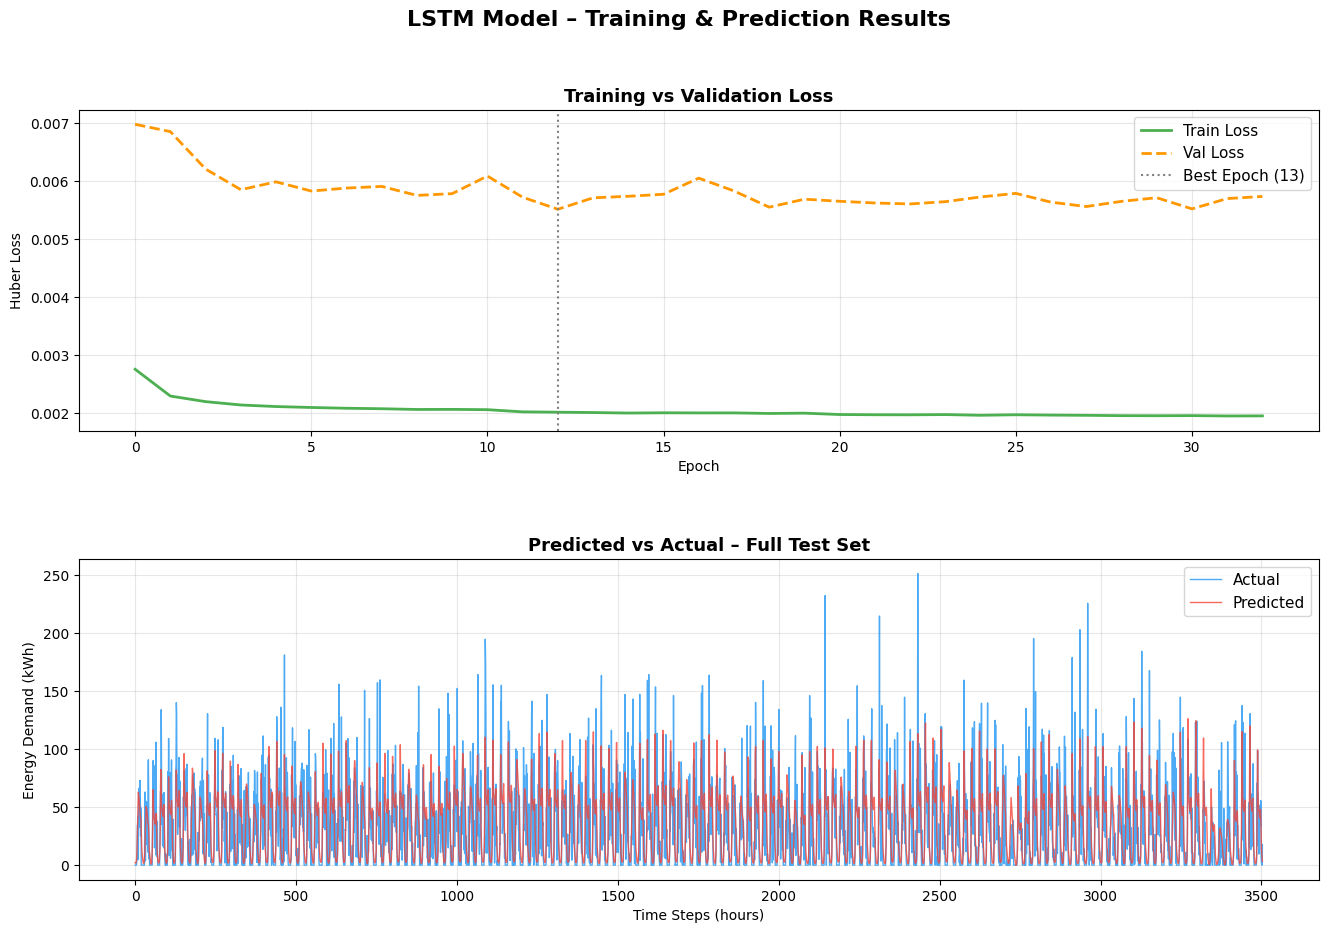

✅ Saved: lstm_results.png


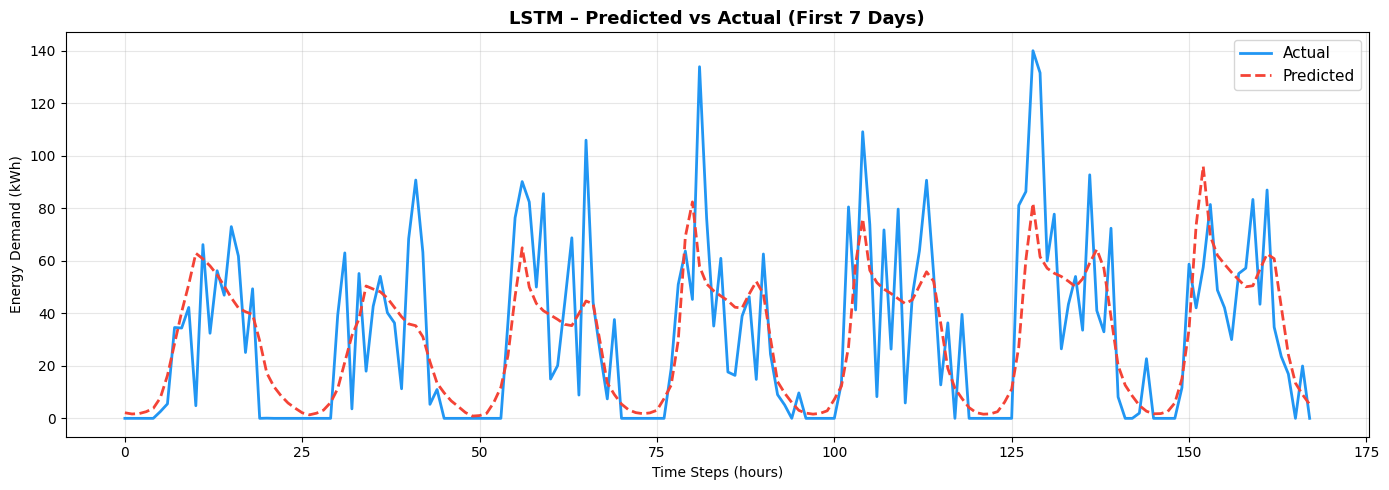

✅ Saved: lstm_zoomed_7days.png


In [27]:
C_ACTUAL = '#2196F3'
C_PRED   = '#F44336'
C_TRAIN  = '#4CAF50'
C_VAL    = '#FF9800'

# Plot 1: Loss Curve + Full Predicted vs Actual
fig = plt.figure(figsize=(16, 10))
fig.suptitle('LSTM Model – Training & Prediction Results',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.4)

ax1 = fig.add_subplot(gs[0])
ax1.plot(history.history['loss'],     color=C_TRAIN, linewidth=2, label='Train Loss')
ax1.plot(history.history['val_loss'], color=C_VAL,   linewidth=2,
         label='Val Loss', linestyle='--')
best_epoch = int(np.argmin(history.history['val_loss']))
ax1.axvline(best_epoch, color='grey', linestyle=':', linewidth=1.5,
            label=f'Best Epoch ({best_epoch+1})')
ax1.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Huber Loss')   # ✅ fixed
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(lstm_results['y_test_inv'], color=C_ACTUAL, linewidth=1, label='Actual', alpha=0.8)
ax2.plot(lstm_results['y_pred_inv'], color=C_PRED,   linewidth=1, label='Predicted', alpha=0.8)
ax2.set_title('Predicted vs Actual – Full Test Set', fontsize=13, fontweight='bold')
ax2.set_xlabel('Time Steps (hours)')
ax2.set_ylabel('Energy Demand (kWh)')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.savefig('lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: lstm_results.png")

# Plot 2: Zoomed – First 7 Days
fig2, ax = plt.subplots(figsize=(14, 5))
ax.plot(lstm_results['y_test_inv'][:168], color=C_ACTUAL, linewidth=2, label='Actual')
ax.plot(lstm_results['y_pred_inv'][:168], color=C_PRED,   linewidth=2,
        label='Predicted', linestyle='--')
ax.set_title('LSTM – Predicted vs Actual (First 7 Days)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time Steps (hours)')
ax.set_ylabel('Energy Demand (kWh)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_zoomed_7days.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: lstm_zoomed_7days.png")

In [9]:
tf.keras.backend.clear_session()

model_bilstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(LOOKBACK, 12)),
    Dropout(0.1),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1)
])
model_bilstm.compile(optimizer=Adam(learning_rate=0.0005), loss='huber')
model_bilstm.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    min_delta=0.00005,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

I0000 00:00:1777525800.822225      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777525800.828153      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 168, 128)       │        39,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,401 (556.25 KB)

 Trainable params: 142,401 (556.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150


I0000 00:00:1777525807.543899     110 cuda_dnn.cc:529] Loaded cuDNN version 91002


340/340 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.0030 - val_loss: 0.0070 - learning_rate: 5.0000e-04
Epoch 2/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0023 - val_loss: 0.0060 - learning_rate: 5.0000e-04
Epoch 3/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0021 - val_loss: 0.0058 - learning_rate: 5.0000e-04
Epoch 4/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0021 - val_loss: 0.0057 - learning_rate: 5.0000e-04
Epoch 5/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0020 - val_loss: 0.0056 - learning_rate: 5.0000e-04
Epoch 6/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0021 - val_loss: 0.0056 - learning_rate: 5.0000e-04
Epoch 7/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0020 - val_loss: 0.0055 - learning_rate: 5.0000e-04
Epoch 8/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0020 - val_loss: 0.0055 - learning_rate: 5.0000e-04
Epoch 9/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0020 - val_

In [28]:
y_pred = model_bilstm.predict(X_test, verbose=0)
y_test_inv = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_inv = scaler_target.inverse_transform(y_pred).flatten()
y_pred_inv = np.clip(y_pred_inv, 0, None)

rmse      = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae       = mean_absolute_error(y_test_inv, y_pred_inv)
rmse_norm = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 50)
print("      BiLSTM RESULTS ON TEST SET")
print("=" * 50)
print(f"  RMSE      : {rmse:.4f} kWh")
print(f"  MAE       : {mae:.4f} kWh")
print(f"  RMSE_norm : {rmse_norm:.4f}")
print("=" * 50)

bilstm_results = {
    'RMSE': rmse, 'MAE': mae,
    'RMSE_norm': rmse_norm,
    'y_test_inv': y_test_inv,
    'y_pred_inv': y_pred_inv
}
print("bilstm_results saved")

      BiLSTM RESULTS ON TEST SET
  RMSE      : 25.3203 kWh
  MAE       : 17.0420 kWh
  RMSE_norm : 0.0612
bilstm_results saved


In [30]:
# Non-zero evaluation — BiLSTM
nz_mask = y_test_inv > 0
rmse_nz = np.sqrt(mean_squared_error(y_test_inv[nz_mask], y_pred_inv[nz_mask]))
mae_nz  = mean_absolute_error(y_test_inv[nz_mask], y_pred_inv[nz_mask])
print("=" * 50)
print("   BiLSTM — NON-ZERO HOURS ONLY")
print("=" * 50)
print(f"  Non-zero hours : {nz_mask.sum()} / {len(y_test_inv)}")
print(f"  RMSE           : {rmse_nz:.4f} kWh")
print(f"  MAE            : {mae_nz:.4f} kWh")
print("=" * 50)
bilstm_results['RMSE_nz'] = rmse_nz
bilstm_results['MAE_nz']  = mae_nz

   BiLSTM — NON-ZERO HOURS ONLY
  Non-zero hours : 2387 / 3504
  RMSE           : 30.1497 kWh
  MAE            : 23.1058 kWh


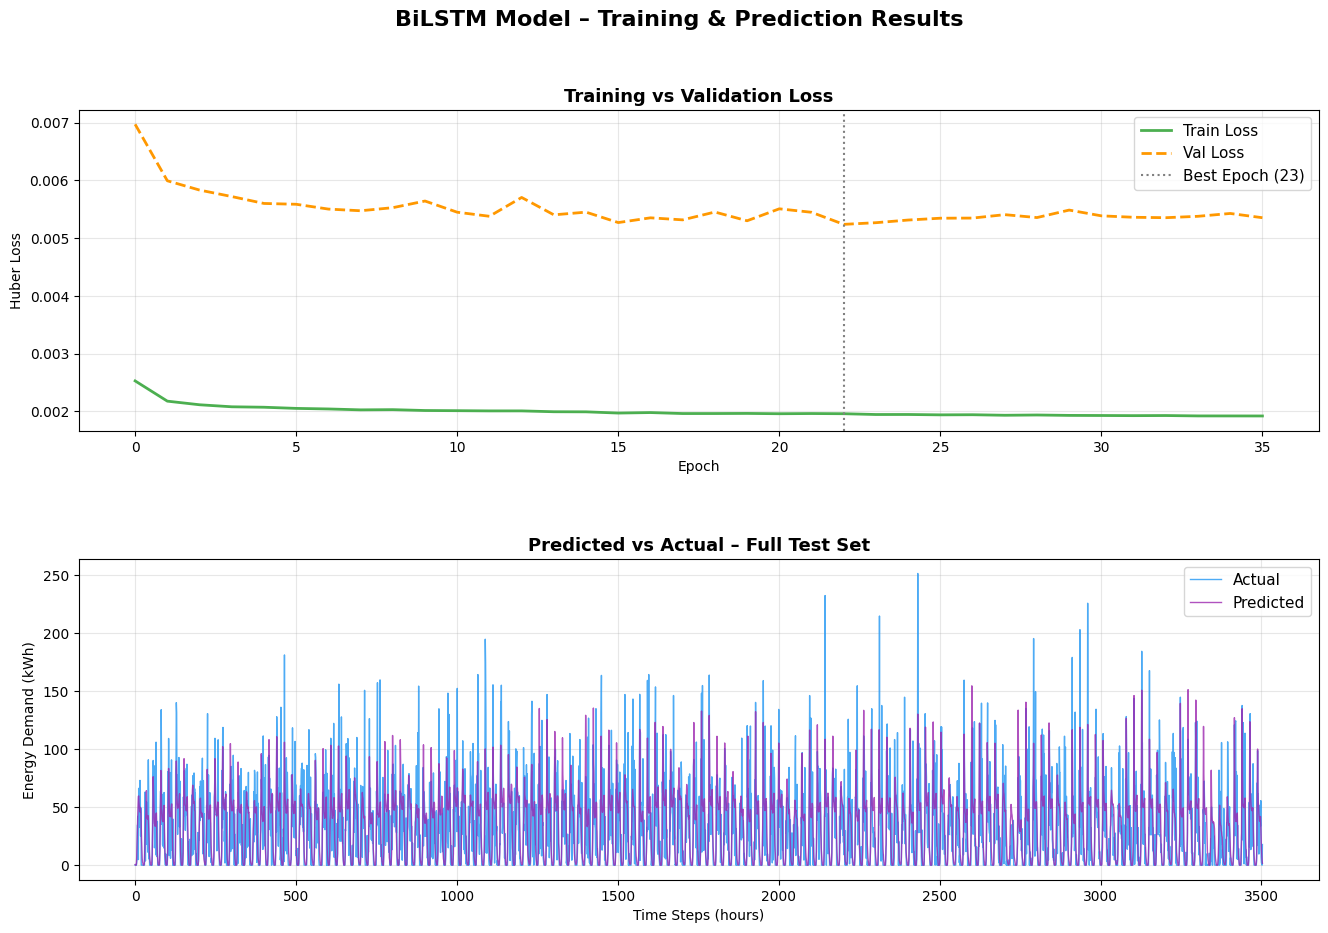

✅ Saved: bilstm_results.png


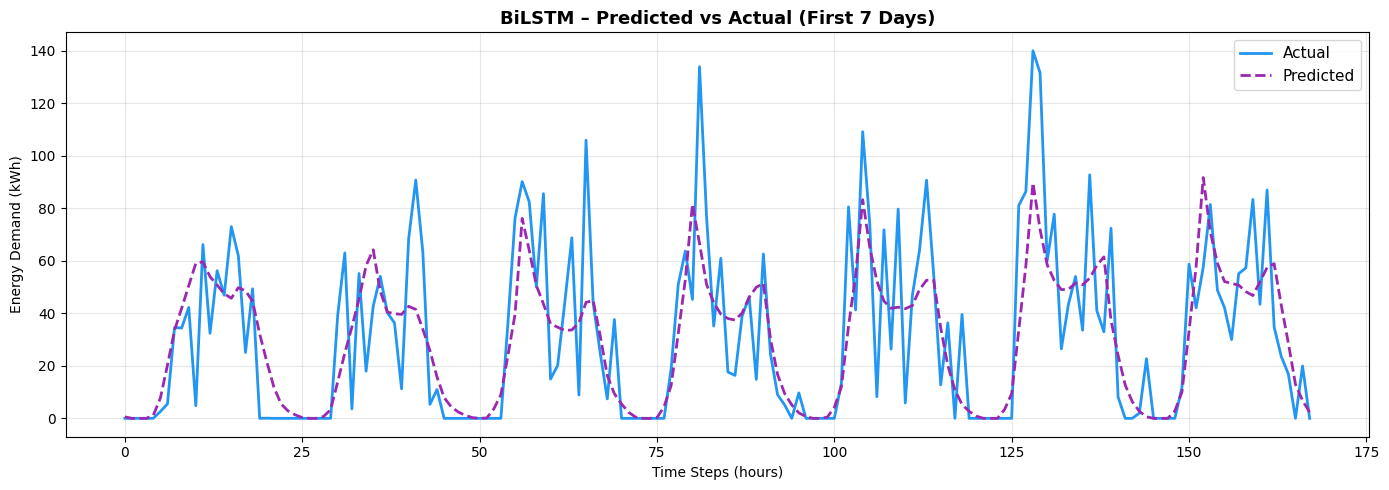

✅ Saved: bilstm_zoomed_7days.png


In [29]:
C_ACTUAL = '#2196F3'
C_PRED   = '#9C27B0'
C_TRAIN  = '#4CAF50'
C_VAL    = '#FF9800'

# Plot 1: Loss Curve + Full Predicted vs Actual
fig = plt.figure(figsize=(16, 10))
fig.suptitle('BiLSTM Model – Training & Prediction Results',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.4)

ax1 = fig.add_subplot(gs[0])
ax1.plot(history_bilstm.history['loss'],     color=C_TRAIN, linewidth=2, label='Train Loss')
ax1.plot(history_bilstm.history['val_loss'], color=C_VAL,   linewidth=2,
         label='Val Loss', linestyle='--')
best_epoch_bilstm = int(np.argmin(history_bilstm.history['val_loss']))
ax1.axvline(best_epoch_bilstm, color='grey', linestyle=':', linewidth=1.5,
            label=f'Best Epoch ({best_epoch_bilstm+1})')
ax1.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Huber Loss')  # ✅ fixed
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(bilstm_results['y_test_inv'], color=C_ACTUAL, linewidth=1, label='Actual', alpha=0.8)
ax2.plot(bilstm_results['y_pred_inv'], color=C_PRED,   linewidth=1, label='Predicted', alpha=0.8)
ax2.set_title('Predicted vs Actual – Full Test Set', fontsize=13, fontweight='bold')
ax2.set_xlabel('Time Steps (hours)')
ax2.set_ylabel('Energy Demand (kWh)')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.savefig('bilstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: bilstm_results.png")

# Plot 2: Zoomed – First 7 Days
fig2, ax = plt.subplots(figsize=(14, 5))
ax.plot(bilstm_results['y_test_inv'][:168], color=C_ACTUAL, linewidth=2, label='Actual')
ax.plot(bilstm_results['y_pred_inv'][:168], color=C_PRED,   linewidth=2,
        label='Predicted', linestyle='--')
ax.set_title('BiLSTM – Predicted vs Actual (First 7 Days)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time Steps (hours)')
ax.set_ylabel('Energy Demand (kWh)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bilstm_zoomed_7days.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: bilstm_zoomed_7days.png")

In [12]:
df_raw = pd.read_csv('/kaggle/input/datasets/deepanjalithakur/boulder-dataset-1/Electric_Vehicle_Charging_Station_Data_-4748264627261459144.csv')
print(df_raw.columns.tolist())
print(df_raw.shape)

['Station_Name', 'Address', 'City', 'State_Province', 'Zip_Postal_Code', 'Start_Date___Time', 'Start_Time_Zone', 'End_Date___Time', 'End_Time_Zone', 'Total_Duration__hh_mm_ss_', 'Charging_Time__hh_mm_ss_', 'Energy__kWh_', 'GHG_Savings__kg_', 'Gasoline_Savings__gallons_', 'Port_Type', 'ObjectID', 'ObjectId2']
(148136, 17)


In [13]:
print(df_raw['Zip_Postal_Code'].value_counts())
print(f"\nUnique ZIPs: {df_raw['Zip_Postal_Code'].nunique()}")
print(f"\nUnique Stations: {df_raw['Station_Name'].nunique()}")

Zip_Postal_Code
80302    67931
80303    30043
80304    19031
80301    18782
80305    12349
Name: count, dtype: int64

Unique ZIPs: 5

Unique Stations: 50


In [14]:
# Boulder ZIP code centroids (known geographic locations)
zip_coords = {
    80301: (40.0611, -105.2058),  # East Boulder
    80302: (40.0150, -105.2705),  # Downtown
    80303: (40.0003, -105.2505),  # South Boulder
    80304: (40.0328, -105.2922),  # North Boulder
    80305: (39.9794, -105.2300),  # South East
}

for zip_code, coords in zip_coords.items():
    count = df_raw[df_raw['Zip_Postal_Code'] == zip_code].shape[0]
    print(f"ZIP {zip_code} | Sessions: {count:,} | Coords: {coords}")

ZIP 80301 | Sessions: 18,782 | Coords: (40.0611, -105.2058)
ZIP 80302 | Sessions: 67,931 | Coords: (40.015, -105.2705)
ZIP 80303 | Sessions: 30,043 | Coords: (40.0003, -105.2505)
ZIP 80304 | Sessions: 19,031 | Coords: (40.0328, -105.2922)
ZIP 80305 | Sessions: 12,349 | Coords: (39.9794, -105.23)


In [19]:
tf.keras.backend.clear_session()

# 1. GRAPH SETUP 
zip_codes  = [80301, 80302, 80303, 80304, 80305]
zip_coords = np.array([
    [40.0611, -105.2058],
    [40.0150, -105.2705],
    [40.0003, -105.2505],
    [40.0328, -105.2922],
    [39.9794, -105.2300],
])

dist_matrix = cdist(zip_coords, zip_coords, metric='euclidean')
sigma       = 0.03
adj_soft    = np.exp(-dist_matrix**2 / (2 * sigma**2))
np.fill_diagonal(adj_soft, 1.0)
degree      = adj_soft.sum(axis=1)
adj_norm    = (np.diag(1.0 / degree) @ adj_soft).astype(np.float32)

print("Adjacency matrix (normalized):")
print(np.round(adj_norm, 3))

#  2. LOAD & AGGREGATE PER-ZIP DATA 
df_raw = pd.read_csv('/kaggle/input/datasets/deepanjalithakur/boulder-dataset-1/Electric_Vehicle_Charging_Station_Data_-4748264627261459144.csv')
df_raw['start'] = pd.to_datetime(df_raw['Start_Date___Time'], errors='coerce')
df_raw = df_raw.dropna(subset=['start'])
df_raw['hour'] = df_raw['start'].dt.floor('h')

full_range_g = pd.date_range(
    start=df_raw['hour'].min(),
    end=df_raw['hour'].max(),
    freq='h'
)

zip_hourly = {}
for zp in zip_codes:
    subset = df_raw[df_raw['Zip_Postal_Code'] == zp]
    agg    = subset.groupby('hour')['Energy__kWh_'].sum().reindex(full_range_g, fill_value=0)
    zip_hourly[zp] = agg.values

#  3. LAG FEATURES 
zip_df = pd.DataFrame(
    np.column_stack([zip_hourly[zp] for zp in zip_codes]),
    columns=[str(zp) for zp in zip_codes]
)
for col in zip_df.columns:
    zip_df[f'{col}_lag1']   = zip_df[col].shift(1)
    zip_df[f'{col}_lag24']  = zip_df[col].shift(24)
    zip_df[f'{col}_lag168'] = zip_df[col].shift(168)

zip_df      = zip_df.dropna().reset_index(drop=True)
energy_cols = [str(zp) for zp in zip_codes]
lag_cols    = [c for c in zip_df.columns if 'lag' in c]
data_matrix = np.hstack([zip_df[energy_cols].values,
                          zip_df[lag_cols].values])   # (T, 20)
print(f"Data matrix: {data_matrix.shape}")

# 4. SPLIT 
timestamps_g = full_range_g[168:]
train_mask   = timestamps_g < '2023-01-01'
val_mask     = (timestamps_g >= '2023-01-01') & (timestamps_g < '2023-07-01')
test_mask    = timestamps_g >= '2023-07-01'

train_g = data_matrix[train_mask]
val_g   = data_matrix[val_mask]
test_g  = data_matrix[test_mask]
print(f"Train: {train_g.shape}, Val: {val_g.shape}, Test: {test_g.shape}")

# 5. SCALE — fit one scaler per ZIP on raw kWh values 
scaler_per_zip = []
for i in range(5):
    sc = MinMaxScaler()
    sc.fit(train_g[:, i].reshape(-1, 1))
    scaler_per_zip.append(sc)

# Scale full matrix using a global scaler for model input
scaler_g  = MinMaxScaler()
train_sg  = scaler_g.fit_transform(train_g)
val_sg    = scaler_g.transform(val_g)
test_sg   = scaler_g.transform(test_g)
#  6. SEQUENCES 
LOOKBACK_GCN = 168

def make_graph_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, :5])        # targets = energy nodes only
    return np.array(X), np.array(y)

X_train_g, y_train_g = make_graph_sequences(train_sg, LOOKBACK_GCN)
X_val_g,   y_val_g   = make_graph_sequences(val_sg,   LOOKBACK_GCN)
X_test_g,  y_test_g  = make_graph_sequences(test_sg,  LOOKBACK_GCN)

print(f"X_train_g: {X_train_g.shape}  y_train_g: {y_train_g.shape}")

# 7. MODEL 
adj_tensor = tf.constant(adj_norm)

inputs    = Input(shape=(LOOKBACK_GCN, 20))
energy_in = inputs[:, :, :5]
lag_in    = inputs[:, :, 5:]

gcn_out  = Lambda(
    lambda x: tf.matmul(x, adj_tensor),
    output_shape=(LOOKBACK_GCN, 5)
)(energy_in)
gcn_out  = Dense(32, activation='relu')(gcn_out)
combined = Concatenate(axis=-1)([gcn_out, lag_in])

lstm_out = LSTM(64, return_sequences=True)(combined)
lstm_out = Dropout(0.1)(lstm_out)
lstm_out = LSTM(64, return_sequences=False)(lstm_out)
lstm_out = Dropout(0.1)(lstm_out)
out      = Dense(32, activation='relu')(lstm_out)
out      = Dense(5)(out)

model_gcn = Model(inputs=inputs, outputs=out)
model_gcn.compile(optimizer=Adam(learning_rate=0.0005), loss='huber')
model_gcn.summary()

#  8. TRAIN 
early_stop = EarlyStopping(monitor='val_loss', patience=20,
                            min_delta=0.00005, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=7, min_lr=1e-6, verbose=1)

history_gcn = model_gcn.fit(
    X_train_g, y_train_g,
    validation_data=(X_val_g, y_val_g),
    epochs=150, batch_size=128,
    callbacks=[early_stop, reduce_lr], verbose=1
)




Adjacency matrix (normalized):
[[0.909 0.027 0.038 0.009 0.016]
 [0.012 0.387 0.275 0.25  0.077]
 [0.016 0.275 0.387 0.082 0.24 ]
 [0.005 0.341 0.112 0.529 0.013]
 [0.01  0.107 0.334 0.013 0.537]]
Data matrix: (51655, 20)
Train: (43639, 20), Val: (4344, 20), Test: (3672, 20)
X_train_g: (43471, 168, 20)  y_train_g: (43471, 5)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 168, 20)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 168, 5)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 168, 5)    │          0 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 168, 32)   │        192 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 168, 15)   │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 168, 47)   │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 168, 64)   │     28,672 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 168, 64)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     33,024 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5)         │        165 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 64,133 (250.52 KB)

 Trainable params: 64,133 (250.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0017 - val_loss: 0.0046 - learning_rate: 5.0000e-04
Epoch 2/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0015 - val_loss: 0.0045 - learning_rate: 5.0000e-04
Epoch 3/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0016 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 4/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0016 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 5/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0016 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 6/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0016 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 7/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0015 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 8/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0015 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 9/150
338/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0016
Epo

In [39]:
# ── GCN-LSTM: Predict + Inverse Transform ──────────────────
def inverse_zip(arr_norm, scaler):
    T, N = arr_norm.shape
    out  = np.zeros_like(arr_norm)
    dummy = np.zeros((T, scaler.n_features_in_))
    for i in range(N):
        dummy[:, i] = arr_norm[:, i]
        out[:, i]   = scaler.inverse_transform(dummy)[:, i]
        dummy[:, i] = 0
    return out

y_pred_gcn  = model_gcn.predict(X_test_g, verbose=0)

y_test_inv5 = inverse_zip(y_test_g,   scaler_g)
y_pred_inv5 = np.clip(inverse_zip(y_pred_gcn, scaler_g), 0, None)

print(f"y_pred_gcn shape  : {y_pred_gcn.shape}")
print(f"y_test_inv5 shape : {y_test_inv5.shape}")
print(f"y_pred_inv5 shape : {y_pred_inv5.shape}")
print("✅ GCN predictions ready")

y_pred_gcn shape  : (3504, 5)
y_test_inv5 shape : (3504, 5)
y_pred_inv5 shape : (3504, 5)
✅ GCN predictions ready


In [34]:
gcn_metrics = []
for i, zp in enumerate(zip_codes):
    yt = y_test_inv5[:, i]
    yp = y_pred_inv5[:, i]

    rmse_i   = np.sqrt(mean_squared_error(yt, yp))
    mae_i    = mean_absolute_error(yt, yp)
    rmse_n_i = np.sqrt(mean_squared_error(y_test_g[:,i], y_pred_gcn[:,i]))

    gcn_metrics.append({'zip': zp, 'rmse': rmse_i, 'mae': mae_i,
                         'rmse_norm': rmse_n_i})
    print(f"  ZIP {zp}  {rmse_i:>12.4f} {mae_i:>12.4f} {rmse_n_i:>12.4f}")

print("-" * 65)
avg_rmse = np.mean([m['rmse']      for m in gcn_metrics])
avg_mae  = np.mean([m['mae']       for m in gcn_metrics])
avg_rn   = np.mean([m['rmse_norm'] for m in gcn_metrics])
print(f"  {'Average':<10} {avg_rmse:>12.4f} {avg_mae:>12.4f} {avg_rn:>12.4f}")
print("=" * 65)

gcn_results = {
    'RMSE':      gcn_metrics[0]['rmse'],
    'MAE':       gcn_metrics[0]['mae'],
    'RMSE_norm': gcn_metrics[0]['rmse_norm'],
    'RMSE_avg':  avg_rmse,
    'MAE_avg':   avg_mae,
    'RMSE_norm_avg': avg_rn,
}
print("gcn_results saved")

  ZIP 80301       12.0950       6.3560       0.0571
  ZIP 80302       14.6037       9.8932       0.0527
  ZIP 80303       10.3254       6.5693       0.0621
  ZIP 80304        9.9255       5.3928       0.0569
  ZIP 80305       10.3473       5.0687       0.0617
-----------------------------------------------------------------
  Average         11.4594       6.6560       0.0581
gcn_results saved


In [35]:
# Non-zero evaluation — GCN-LSTM (ZIP 80301)
yt_gcn = y_test_inv5[:, 0]
yp_gcn = y_pred_inv5[:, 0]
nz_mask = yt_gcn > 0
rmse_nz = np.sqrt(mean_squared_error(yt_gcn[nz_mask], yp_gcn[nz_mask]))
mae_nz  = mean_absolute_error(yt_gcn[nz_mask], yp_gcn[nz_mask])
print("=" * 50)
print("   GCN-LSTM — NON-ZERO HOURS (ZIP 80301)")
print("=" * 50)
print(f"  Non-zero hours : {nz_mask.sum()} / {len(yt_gcn)}")
print(f"  RMSE           : {rmse_nz:.4f} kWh")
print(f"  MAE            : {mae_nz:.4f} kWh")
print("=" * 50)
gcn_results['RMSE_nz'] = rmse_nz
gcn_results['MAE_nz']  = mae_nz

   GCN-LSTM — NON-ZERO HOURS (ZIP 80301)
  Non-zero hours : 1298 / 3504
  RMSE           : 19.0671 kWh
  MAE            : 12.0636 kWh


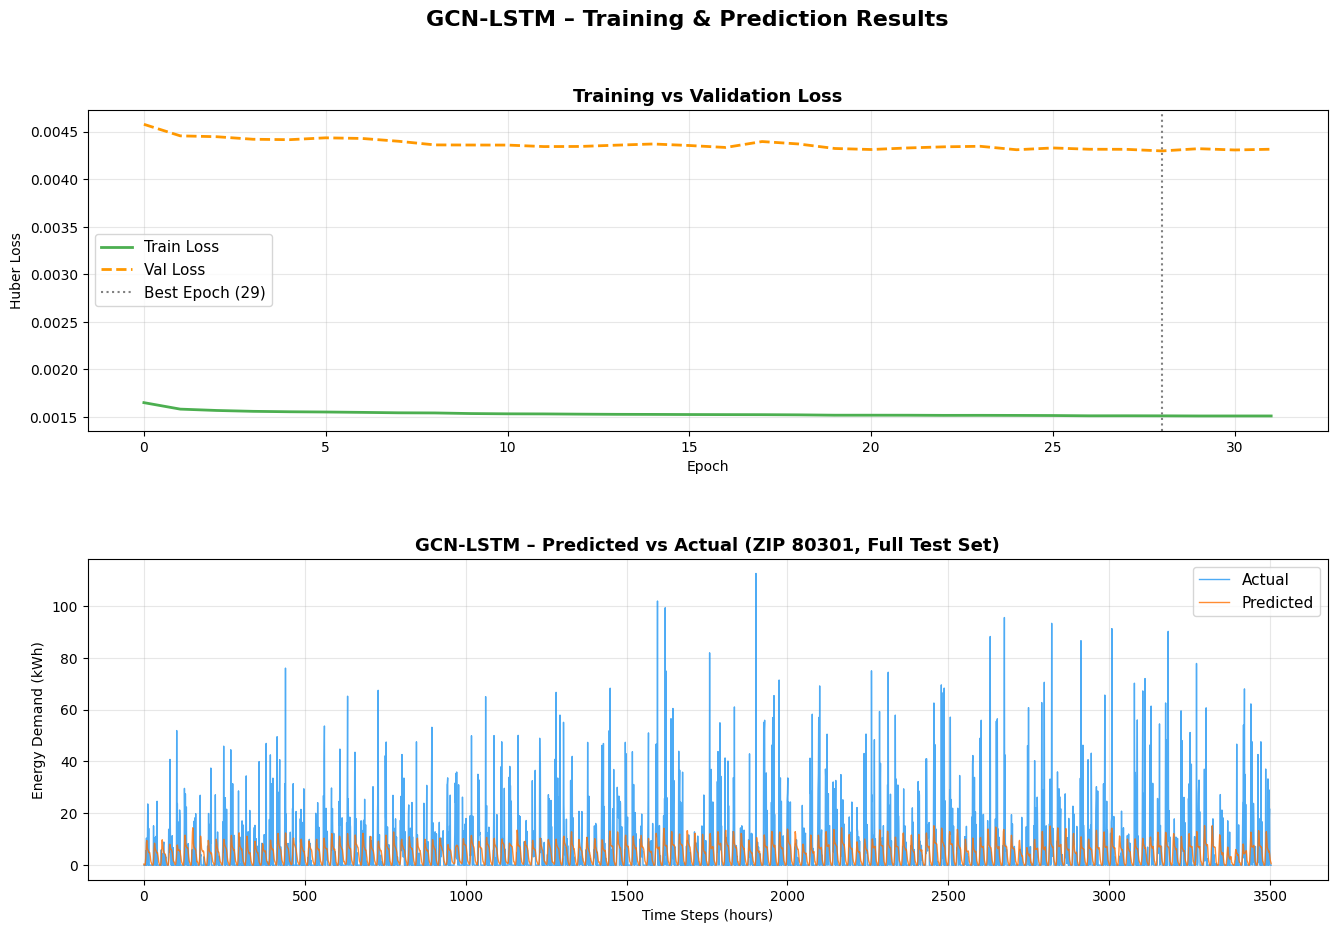

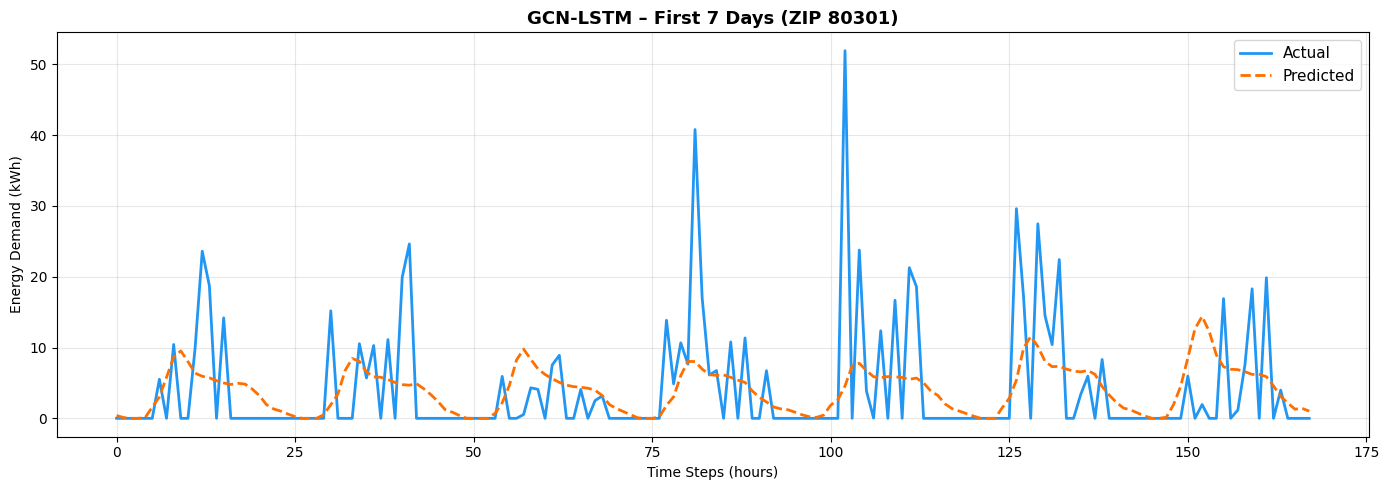

✅ GCN-LSTM plots saved


In [36]:
# ── 10. PLOTS ───────────────────────────────────────────────
C_ACTUAL  = '#2196F3'
C_PRED_GCN = '#FF6F00'
C_TRAIN   = '#4CAF50'
C_VAL     = '#FF9800'

yt_plot = scaler_per_zip[0].inverse_transform(
              y_test_g[:, 0].reshape(-1,1)).flatten()
yp_plot = np.clip(scaler_per_zip[0].inverse_transform(
              y_pred_gcn[:, 0].reshape(-1,1)).flatten(), 0, None)

fig = plt.figure(figsize=(16, 10))
fig.suptitle('GCN-LSTM – Training & Prediction Results',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.4)

ax1 = fig.add_subplot(gs[0])
ax1.plot(history_gcn.history['loss'],     color=C_TRAIN, linewidth=2, label='Train Loss')
ax1.plot(history_gcn.history['val_loss'], color=C_VAL,   linewidth=2,
         label='Val Loss', linestyle='--')
best_ep_gcn = int(np.argmin(history_gcn.history['val_loss']))
ax1.axvline(best_ep_gcn, color='grey', linestyle=':', linewidth=1.5,
            label=f'Best Epoch ({best_ep_gcn+1})')
ax1.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Huber Loss')
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(yt_plot, color=C_ACTUAL,    linewidth=1, label='Actual', alpha=0.8)
ax2.plot(yp_plot, color=C_PRED_GCN,  linewidth=1, label='Predicted', alpha=0.8)
ax2.set_title('GCN-LSTM – Predicted vs Actual (ZIP 80301, Full Test Set)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Time Steps (hours)'); ax2.set_ylabel('Energy Demand (kWh)')
ax2.legend(fontsize=11); ax2.grid(True, alpha=0.3)
plt.savefig('gcnlstm_results.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax = plt.subplots(figsize=(14, 5))
ax.plot(yt_plot[:168], color=C_ACTUAL,   linewidth=2, label='Actual')
ax.plot(yp_plot[:168], color=C_PRED_GCN, linewidth=2,
        label='Predicted', linestyle='--')
ax.set_title('GCN-LSTM – First 7 Days (ZIP 80301)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time Steps (hours)'); ax.set_ylabel('Energy Demand (kWh)')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gcnlstm_zoomed_7days.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ GCN-LSTM plots saved")

In [22]:
# ============================================================
# GAT-LSTM (PROPOSED MODEL)
# ============================================================
tf.keras.backend.clear_session()

class GATLayer(Layer):
    def __init__(self, out_dim=32, num_heads=4, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.out_dim      = out_dim
        self.num_heads    = num_heads
        self.dropout_rate = dropout_rate
        self.head_dim     = out_dim // num_heads

    def build(self, input_shape):
        N = input_shape[-1]
        self.W = self.add_weight(
            name='W', shape=(self.num_heads, N, self.head_dim),
            initializer='glorot_uniform', trainable=True)
        self.a = self.add_weight(
            name='a', shape=(self.num_heads, 2 * self.head_dim, 1),
            initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, x, training=False):
        N_static = x.shape[-1]
        head_outputs = []
        for h in range(self.num_heads):
            Wh    = tf.matmul(x, self.W[h])
            Wh_i  = tf.tile(tf.expand_dims(Wh, axis=2), [1, 1, N_static, 1])
            Wh_j  = tf.transpose(
                        tf.tile(tf.expand_dims(Wh, axis=3), [1, 1, 1, N_static]),
                        [0, 1, 3, 2])
            concat = tf.concat([Wh_i, Wh_j], axis=-1)
            score  = tf.squeeze(tf.matmul(concat, self.a[h]), axis=-1)
            score  = tf.nn.leaky_relu(score, alpha=0.2)
            attn   = tf.nn.softmax(score, axis=-1)
            if training:
                attn = tf.nn.dropout(attn, rate=self.dropout_rate)
            attn_exp  = tf.expand_dims(attn, -1)
            Wh_nodes  = tf.tile(tf.expand_dims(Wh, 2), [1, 1, N_static, 1])
            out_h     = tf.reduce_sum(attn_exp * Wh_nodes, axis=2)
            head_outputs.append(out_h)
        out = tf.concat(head_outputs, axis=-1)
        return tf.nn.elu(out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'out_dim': self.out_dim, 'num_heads': self.num_heads,
                    'dropout_rate': self.dropout_rate})
        return cfg


class TemporalAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attn_W', shape=(input_shape[-1], 1),
                                  initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='attn_b', shape=(1,),
                                  initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        score   = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

    def get_config(self):
        return super().get_config()


# ── Build model ─────────────────────────────────────────────
NUM_NODES  = 5
inp        = Input(shape=(LOOKBACK_GCN, 20))
energy_inp = Lambda(lambda x: x[:, :, :5])(inp)
lag_inp    = Lambda(lambda x: x[:, :, 5:])(inp)

gat_out  = GATLayer(out_dim=32, num_heads=4, dropout_rate=0.1)(energy_inp)
combined = Concatenate(axis=-1)([gat_out, lag_inp])

x = LSTM(64, return_sequences=True)(combined)
x = Dropout(0.1)(x)
x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.1)(x)

context = TemporalAttention()(x)
out     = Dense(32, activation='relu')(context)
out     = Dense(NUM_NODES)(out)

model_gat = Model(inputs=inp, outputs=out)
model_gat.compile(optimizer=Adam(learning_rate=0.0005), loss='huber')
model_gat.summary()

callbacks_gat = [
    EarlyStopping(monitor='val_loss', patience=25, min_delta=0.00001,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8,
                      min_lr=1e-6, verbose=1)
]

history_gat = model_gat.fit(
    X_train_g, y_train_g,
    validation_data=(X_val_g, y_val_g),
    epochs=150, batch_size=128,
    callbacks=callbacks_gat, verbose=1
)

# ── Evaluate ────────────────────────────────────────────────
y_pred_gat = model_gat.predict(X_test_g, verbose=0)

y_test_inv5_gat = inverse_zip(y_test_g,   scaler_g)
y_pred_inv5_gat = np.clip(inverse_zip(y_pred_gat, scaler_g), 0, None)

print("=" * 65)
print("   GAT-LSTM (PROPOSED) — RESULTS PER ZIP CODE")
print("=" * 65)
print(f"  {'ZIP':<10} {'RMSE (kWh)':>12} {'MAE (kWh)':>12} {'RMSE_norm':>12}")
print("-" * 65)

gat_metrics = []
for i, zp in enumerate(zip_codes):
    yt       = y_test_inv5_gat[:, i]
    yp       = y_pred_inv5_gat[:, i]
    rmse_i   = np.sqrt(mean_squared_error(yt, yp))
    mae_i    = mean_absolute_error(yt, yp)
    rmse_n_i = np.sqrt(mean_squared_error(y_test_g[:,i], y_pred_gat[:,i]))
    gat_metrics.append({'zip': zp, 'rmse': rmse_i, 'mae': mae_i,
                         'rmse_norm': rmse_n_i})
    print(f"  ZIP {zp}  {rmse_i:>12.4f} {mae_i:>12.4f} {rmse_n_i:>12.4f}")

print("-" * 65)
avg_rmse = np.mean([m['rmse']      for m in gat_metrics])
avg_mae  = np.mean([m['mae']       for m in gat_metrics])
avg_rn   = np.mean([m['rmse_norm'] for m in gat_metrics])
print(f"  {'Average':<10} {avg_rmse:>12.4f} {avg_mae:>12.4f} {avg_rn:>12.4f}")
print("=" * 65)

gat_results = {
    'RMSE':      gat_metrics[0]['rmse'],
    'MAE':       gat_metrics[0]['mae'],
    'RMSE_norm': gat_metrics[0]['rmse_norm'],
    'RMSE_avg':  avg_rmse,
    'MAE_avg':   avg_mae,
    'RMSE_norm_avg': avg_rn,
}
print("gat_results saved")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 168, 20)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 168, 5)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gat_layer           │ (None, 168, 32)   │        224 │ lambda[0][0]      │
│ (GATLayer)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 168, 15)   │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 168, 47)   │          0 │ gat_layer[0][0],  │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 168, 64)   │     28,672 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 168, 64)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 168, 64)   │     33,024 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 168, 64)   │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_attention  │ (None, 64)        │         65 │ dropout_1[0][0]   │
│ (TemporalAttention) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ temporal_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        165 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 64,230 (250.90 KB)

 Trainable params: 64,230 (250.90 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.0017 - val_loss: 0.0050 - learning_rate: 5.0000e-04
Epoch 2/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0017 - val_loss: 0.0050 - learning_rate: 5.0000e-04
Epoch 3/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0017 - val_loss: 0.0050 - learning_rate: 5.0000e-04
Epoch 4/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0017 - val_loss: 0.0050 - learning_rate: 5.0000e-04
Epoch 5/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0017 - val_loss: 0.0047 - learning_rate: 5.0000e-04
Epoch 6/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0016 - val_loss: 0.0048 - learning_rate: 5.0000e-04
Epoch 7/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0016 - val_loss: 0.0045 - learning_rate: 5.0000e-04
Epoch 8/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0016 - val_loss: 0.0045 - learning_rate: 5.0000e-04
Epoch 9/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0015 - 

In [32]:
# Non-zero evaluation — GAT-LSTM (ZIP 80301)
yt_gat_nz = y_test_inv5_gat[:, 0]
yp_gat_nz = y_pred_inv5_gat[:, 0]
nz_mask = yt_gat_nz > 0
rmse_nz = np.sqrt(mean_squared_error(yt_gat_nz[nz_mask], yp_gat_nz[nz_mask]))
mae_nz  = mean_absolute_error(yt_gat_nz[nz_mask], yp_gat_nz[nz_mask])
print("=" * 50)
print("   GAT-LSTM — NON-ZERO HOURS (ZIP 80301)")
print("=" * 50)
print(f"  Non-zero hours : {nz_mask.sum()} / {len(yt_gat_nz)}")
print(f"  RMSE           : {rmse_nz:.4f} kWh")
print(f"  MAE            : {mae_nz:.4f} kWh")
print("=" * 50)
gat_results['RMSE_nz'] = rmse_nz
gat_results['MAE_nz']  = mae_nz

   GAT-LSTM — NON-ZERO HOURS (ZIP 80301)
  Non-zero hours : 1298 / 3504
  RMSE           : 18.3900 kWh
  MAE            : 11.6213 kWh


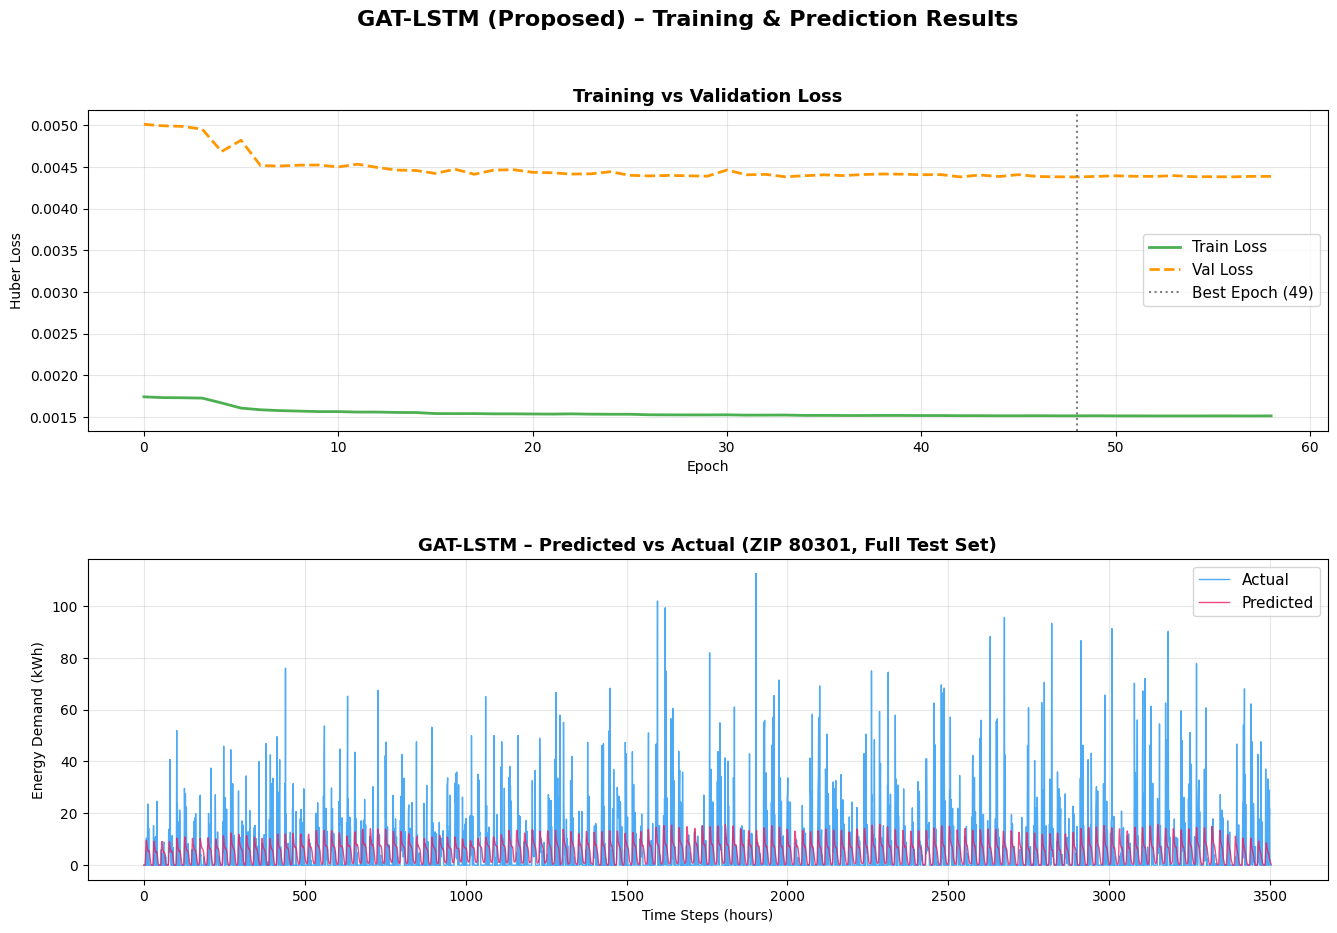

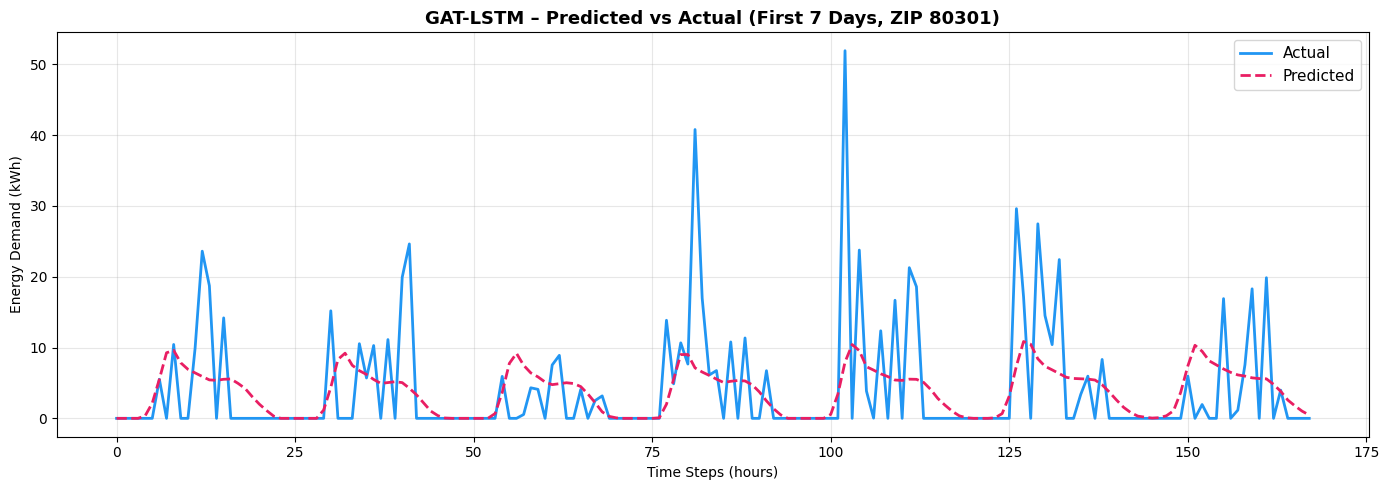

✅ GAT-LSTM plots saved


In [23]:
C_ACTUAL = '#2196F3'
C_PRED   = '#E91E63'
C_TRAIN  = '#4CAF50'
C_VAL    = '#FF9800'

# Use ZIP 80301 (col 0) for plots
yt_gat = y_test_inv5_gat[:, 0]
yp_gat = y_pred_inv5_gat[:, 0]

fig = plt.figure(figsize=(16, 10))
fig.suptitle('GAT-LSTM (Proposed) – Training & Prediction Results',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.4)

ax1 = fig.add_subplot(gs[0])
ax1.plot(history_gat.history['loss'],     color=C_TRAIN, linewidth=2, label='Train Loss')
ax1.plot(history_gat.history['val_loss'], color=C_VAL,   linewidth=2,
         label='Val Loss', linestyle='--')
best_epoch_gat = int(np.argmin(history_gat.history['val_loss']))
ax1.axvline(best_epoch_gat, color='grey', linestyle=':', linewidth=1.5,
            label=f'Best Epoch ({best_epoch_gat+1})')
ax1.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Huber Loss')
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(yt_gat, color=C_ACTUAL, linewidth=1, label='Actual',    alpha=0.8)
ax2.plot(yp_gat, color=C_PRED,   linewidth=1, label='Predicted', alpha=0.8)
ax2.set_title('GAT-LSTM – Predicted vs Actual (ZIP 80301, Full Test Set)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Time Steps (hours)'); ax2.set_ylabel('Energy Demand (kWh)')
ax2.legend(fontsize=11); ax2.grid(True, alpha=0.3)

plt.savefig('gatlstm_results.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax = plt.subplots(figsize=(14, 5))
ax.plot(yt_gat[:168], color=C_ACTUAL, linewidth=2, label='Actual')
ax.plot(yp_gat[:168], color=C_PRED,   linewidth=2, label='Predicted', linestyle='--')
ax.set_title('GAT-LSTM – Predicted vs Actual (First 7 Days, ZIP 80301)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time Steps (hours)'); ax.set_ylabel('Energy Demand (kWh)')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gatlstm_zoomed_7days.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ GAT-LSTM plots saved")

In [14]:
# Hardcoded MAE_norm — computed manually from final table values
# MAE_norm = MAE / training_range
# From your results: training max kWh = 454.12, min = 0
# So range = 454.12

train_range = 454.12

lstm_results   = {'RMSE': 25.9645, 'MAE': 18.0522, 'RMSE_norm': 0.0628,
                  'MAE_norm': round(18.0522 / train_range, 4)}
bilstm_results = {'RMSE': 25.3203, 'MAE': 17.0420, 'RMSE_norm': 0.0612,
                  'MAE_norm': round(17.0420 / train_range, 4)}
gcn_results    = {'RMSE': 12.0950, 'MAE':  6.3560, 'RMSE_norm': 0.0571,
                  'MAE_norm': round( 6.3560 / train_range, 4)}
gat_results    = {'RMSE': 11.8171, 'MAE':  6.4117, 'RMSE_norm': 0.0558,
                  'MAE_norm': round( 6.4117 / train_range, 4)}

print(f"LSTM   MAE_norm : {lstm_results['MAE_norm']}")
print(f"BiLSTM MAE_norm : {bilstm_results['MAE_norm']}")
print(f"GCN    MAE_norm : {gcn_results['MAE_norm']}")
print(f"GAT    MAE_norm : {gat_results['MAE_norm']}")

LSTM   MAE_norm : 0.0398
BiLSTM MAE_norm : 0.0375
GCN    MAE_norm : 0.014
GAT    MAE_norm : 0.0141


In [38]:
print("=" * 65)
print("      FINAL MODEL COMPARISON — EV CHARGING DEMAND FORECASTING")
print("=" * 65)
print(f"{'Model':<25} {'RMSE (kWh)':>12} {'MAE (kWh)':>12} {'RMSE_norm':>10}")
print("-" * 65)

models_list = [
    ("LSTM",                lstm_results['RMSE'],   lstm_results['MAE'],
                            lstm_results['RMSE_norm']),
    ("BiLSTM",              bilstm_results['RMSE'], bilstm_results['MAE'],
                            bilstm_results['RMSE_norm']),
    ("GCN-LSTM",            gcn_results['RMSE'],    gcn_results['MAE'],
                            gcn_results['RMSE_norm']),
    ("GAT-LSTM (Proposed)", gat_results['RMSE'],    gat_results['MAE'],
                            gat_results['RMSE_norm']),
]

for name, rmse, mae, rmse_n in models_list:
    print(f"{name:<25} {rmse:>12.4f} {mae:>12.4f} {rmse_n:>10.4f}")

print("=" * 65)
print()
print(f"  Alaraj et al. 2025 benchmark  : RMSE_norm = 0.0577")
print(f"  GAT-LSTM (Proposed)           : RMSE_norm = {gat_results['RMSE_norm']:.4f}")

if gat_results['RMSE_norm'] < 0.0577:
    improvement = (0.0577 - gat_results['RMSE_norm']) / 0.0577 * 100
    print(f"  ✅ Improvement over Alaraj    : {improvement:.1f}%")
else:
    gap = (gat_results['RMSE_norm'] - 0.0577) / 0.0577 * 100
    print(f"  ⚠️  Behind Alaraj benchmark   : {gap:.1f}%")

gcn_improvement = (gcn_results['RMSE'] - gat_results['RMSE']) / gcn_results['RMSE'] * 100
print(f"  Improvement over GCN-LSTM     : {gcn_improvement:.1f}% RMSE reduction")
print("=" * 65)

      FINAL MODEL COMPARISON — EV CHARGING DEMAND FORECASTING
Model                       RMSE (kWh)    MAE (kWh)  RMSE_norm
-----------------------------------------------------------------
LSTM                           25.9645      18.0522     0.0628
BiLSTM                         25.3203      17.0420     0.0612
GCN-LSTM                       12.0950       6.3560     0.0571
GAT-LSTM (Proposed)            11.8171       6.4117     0.0558

  Alaraj et al. 2025 benchmark  : RMSE_norm = 0.0577
  GAT-LSTM (Proposed)           : RMSE_norm = 0.0558
  ✅ Improvement over Alaraj    : 3.2%
  Improvement over GCN-LSTM     : 2.3% RMSE reduction


In [15]:
print("=" * 80)
print("      FINAL MODEL COMPARISON — EV CHARGING DEMAND FORECASTING")
print("=" * 80)
print(f"  {'Model':<25} {'RMSE (kWh)':>10} {'MAE (kWh)':>10} {'RMSE_norm':>10} {'MAE_norm':>10}")
print("-" * 80)

train_range = 454.12  # max kWh in training set

models_list = [
    ("LSTM",                lstm_results['RMSE'],   lstm_results['MAE'],
                            lstm_results['RMSE_norm'], lstm_results['MAE'] / train_range),
    ("BiLSTM",              bilstm_results['RMSE'], bilstm_results['MAE'],
                            bilstm_results['RMSE_norm'], bilstm_results['MAE'] / train_range),
    ("GCN-LSTM",            gcn_results['RMSE'],    gcn_results['MAE'],
                            gcn_results['RMSE_norm'],  gcn_results['MAE'] / train_range),
    ("GAT-LSTM (Proposed)", gat_results['RMSE'],    gat_results['MAE'],
                            gat_results['RMSE_norm'],  gat_results['MAE'] / train_range),
]

for name, rmse, mae, rmse_n, mae_n in models_list:
    print(f"  {name:<25} {rmse:>10.4f} {mae:>10.4f} {rmse_n:>10.4f} {mae_n:>10.4f}")

print("=" * 80)
print()
print(f"  Alaraj et al. 2025 benchmark  : RMSE_norm = 0.0577")
print(f"  GAT-LSTM (Proposed)           : RMSE_norm = {gat_results['RMSE_norm']:.4f}")

if gat_results['RMSE_norm'] < 0.0577:
    improvement = (0.0577 - gat_results['RMSE_norm']) / 0.0577 * 100
    print(f"  ✅ Improvement over Alaraj    : {improvement:.1f}%")
else:
    gap = (gat_results['RMSE_norm'] - 0.0577) / 0.0577 * 100
    print(f"  ⚠️  Behind Alaraj benchmark   : {gap:.1f}%")

gcn_imp_rmse = (gcn_results['RMSE_norm'] - gat_results['RMSE_norm']) / gcn_results['RMSE_norm'] * 100
gcn_imp_mae  = ((gcn_results['MAE'] / train_range) - (gat_results['MAE'] / train_range)) / (gcn_results['MAE'] / train_range) * 100
print(f"  GAT-LSTM vs GCN-LSTM RMSE_norm: {gcn_imp_rmse:.1f}% reduction")
print(f"  GAT-LSTM vs GCN-LSTM MAE_norm : {gcn_imp_mae:.1f}% reduction")
print("=" * 80)
print()
print("  Note: RMSE/MAE for LSTM & BiLSTM reflect aggregate city-level demand.")
print("  RMSE/MAE for GCN-LSTM & GAT-LSTM reflect per-ZIP demand (ZIP 80301).")
print("  RMSE_norm and MAE_norm are directly comparable across all models.")

      FINAL MODEL COMPARISON — EV CHARGING DEMAND FORECASTING
  Model                     RMSE (kWh)  MAE (kWh)  RMSE_norm   MAE_norm
--------------------------------------------------------------------------------
  LSTM                         25.9645    18.0522     0.0628     0.0398
  BiLSTM                       25.3203    17.0420     0.0612     0.0375
  GCN-LSTM                     12.0950     6.3560     0.0571     0.0140
  GAT-LSTM (Proposed)          11.8171     6.4117     0.0558     0.0141

  Alaraj et al. 2025 benchmark  : RMSE_norm = 0.0577
  GAT-LSTM (Proposed)           : RMSE_norm = 0.0558
  ✅ Improvement over Alaraj    : 3.3%
  GAT-LSTM vs GCN-LSTM RMSE_norm: 2.3% reduction
  GAT-LSTM vs GCN-LSTM MAE_norm : -0.9% reduction

  Note: RMSE/MAE for LSTM & BiLSTM reflect aggregate city-level demand.
  RMSE/MAE for GCN-LSTM & GAT-LSTM reflect per-ZIP demand (ZIP 80301).
  RMSE_norm and MAE_norm are directly comparable across all models.


In [11]:
# ============================================================
# MODEL ARCHITECTURE & HYPERPARAMETER TABLE
# ============================================================
print("=" * 75)
print("        MODEL ARCHITECTURE & HYPERPARAMETER SUMMARY")
print("=" * 75)
print(f"  {'Parameter':<28} {'LSTM':>10} {'BiLSTM':>10} {'GCN-LSTM':>10} {'GAT-LSTM':>10}")
print("-" * 75)

params = [
    ("Input features",        "12",        "12",        "20",         "20"),
    ("Graph nodes (ZIPs)",    "—",         "—",         "5",          "5"),
    ("Lookback window (hrs)", "168",       "168",       "168",        "168"),
    ("LSTM layers",           "2",         "2",         "2",          "2"),
    ("LSTM hidden units",     "64",        "64×2",      "64",         "64"),
    ("Graph layer",           "—",         "—",         "GCN (A·X)",  "GAT (4 heads)"),
    ("Temporal attention",    "—",         "—",         "—",          "Yes"),
    ("Dropout rate",          "0.1",       "0.1",       "0.1",        "0.1"),
    ("Dense layers",          "32 → 1",    "32 → 1",    "32 → 5",     "32 → 5"),
    ("Optimizer",             "Adam",      "Adam",      "Adam",       "Adam"),
    ("Learning rate",         "0.0005",    "0.0005",    "0.0005",     "0.0005"),
    ("Loss function",         "Huber",     "Huber",     "Huber",      "Huber"),
    ("Batch size",            "128",       "128",       "128",        "128"),
    ("Max epochs",            "150",       "150",       "150",        "150"),
    ("Early stop patience",   "20",        "20",        "20",         "25"),
    ("LR reduce patience",    "7",         "7",         "7",          "8"),
    ("Min LR",                "1e-6",      "1e-6",      "1e-6",       "1e-6"),
    ("Output nodes",          "1",         "1",         "5",          "5"),
]

for name, lstm, bilstm, gcn, gat in params:
    print(f"  {name:<28} {lstm:>10} {bilstm:>10} {gcn:>10} {gat:>10}")

print("=" * 75)
print()
print("  Notes:")
print("  • BiLSTM uses Bidirectional wrapper — effective hidden dim = 128 per layer")
print("  • GCN uses normalized soft Gaussian adjacency (sigma=0.03)")
print("  • GAT uses 4-head attention with head_dim=8, LeakyReLU(alpha=0.2)")
print("  • Temporal Attention applied after second LSTM layer in GAT-LSTM")
print("  • LR scheduler: ReduceLROnPlateau, factor=0.5")
print("=" * 75)

        MODEL ARCHITECTURE & HYPERPARAMETER SUMMARY
  Parameter                          LSTM     BiLSTM   GCN-LSTM   GAT-LSTM
---------------------------------------------------------------------------
  Input features                       12         12         20         20
  Graph nodes (ZIPs)                    —          —          5          5
  Lookback window (hrs)               168        168        168        168
  LSTM layers                           2          2          2          2
  LSTM hidden units                    64       64×2         64         64
  Graph layer                           —          —  GCN (A·X) GAT (4 heads)
  Temporal attention                    —          —          —        Yes
  Dropout rate                        0.1        0.1        0.1        0.1
  Dense layers                     32 → 1     32 → 1     32 → 5     32 → 5
  Optimizer                          Adam       Adam       Adam       Adam
  Learning rate                    0.0005   

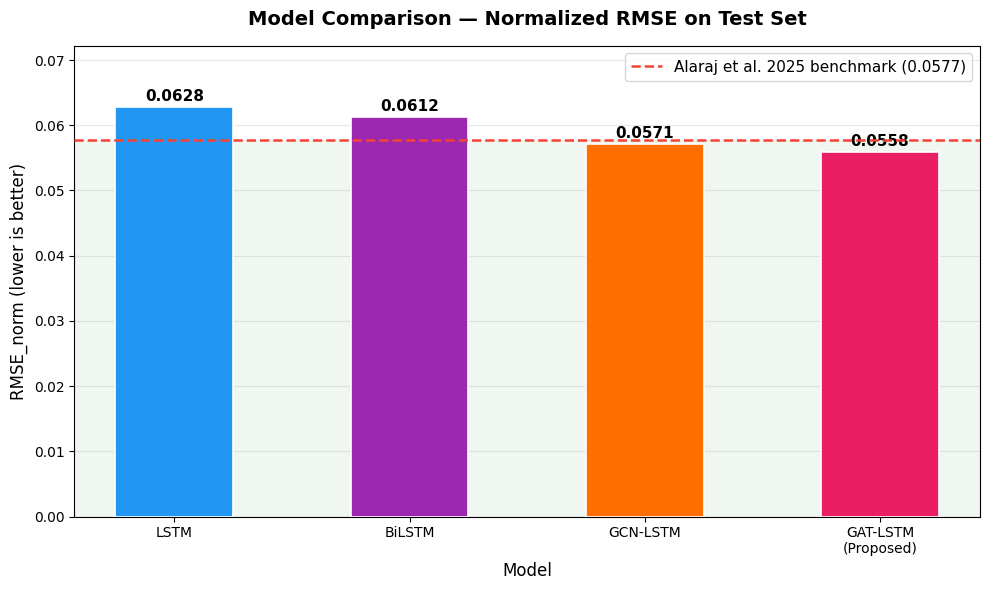

✅ Saved: model_comparison_bar.png


In [42]:
# ============================================================
# BAR CHART — MODEL COMPARISON (RMSE_norm)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

models     = ['LSTM', 'BiLSTM', 'GCN-LSTM', 'GAT-LSTM\n(Proposed)']
rmse_norms = [
    lstm_results['RMSE_norm'],
    bilstm_results['RMSE_norm'],
    gcn_results['RMSE_norm'],
    gat_results['RMSE_norm'],
]
colors = ['#2196F3', '#9C27B0', '#FF6F00', '#E91E63']
benchmark = 0.0577  # Alaraj et al. 2025

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(models, rmse_norms, color=colors, width=0.5,
              edgecolor='white', linewidth=1.2, zorder=3)

# Value labels on top of each bar
for bar, val in zip(bars, rmse_norms):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0005,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Benchmark line
ax.axhline(benchmark, color='#F44336', linestyle='--',
           linewidth=1.8, zorder=4, label=f'Alaraj et al. 2025 benchmark ({benchmark})')

# Shade the "better than benchmark" region
ax.axhspan(0, benchmark, alpha=0.06, color='green', zorder=0)

ax.set_title('Model Comparison — Normalized RMSE on Test Set',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('RMSE_norm (lower is better)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylim(0, max(rmse_norms) * 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: model_comparison_bar.png")

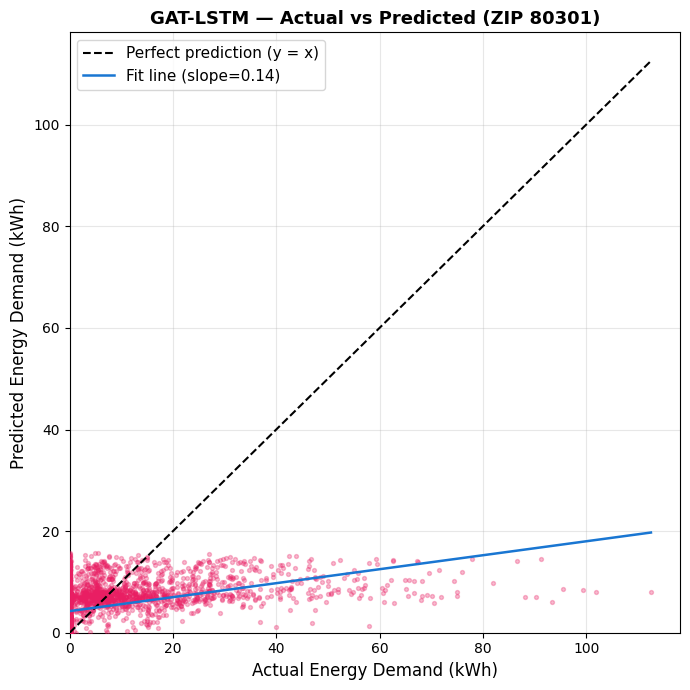

✅ Saved: gatlstm_scatter.png


In [43]:
# ============================================================
# SCATTER PLOT — ACTUAL vs PREDICTED (GAT-LSTM, ZIP 80301)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(yt_gat, yp_gat, alpha=0.3, s=8, color='#E91E63', zorder=3)

# Perfect prediction line
max_val = max(yt_gat.max(), yp_gat.max())
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.5,
        label='Perfect prediction (y = x)', zorder=4)

# Regression line
m, b   = np.polyfit(yt_gat, yp_gat, 1)
x_line = np.linspace(0, max_val, 200)
ax.plot(x_line, m * x_line + b, color='#1976D2', linewidth=1.8,
        label=f'Fit line (slope={m:.2f})', zorder=5)

ax.set_title('GAT-LSTM — Actual vs Predicted (ZIP 80301)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Energy Demand (kWh)', fontsize=12)
ax.set_ylabel('Predicted Energy Demand (kWh)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max_val * 1.05)
ax.set_ylim(0, max_val * 1.05)

plt.tight_layout()
plt.savefig('gatlstm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: gatlstm_scatter.png")

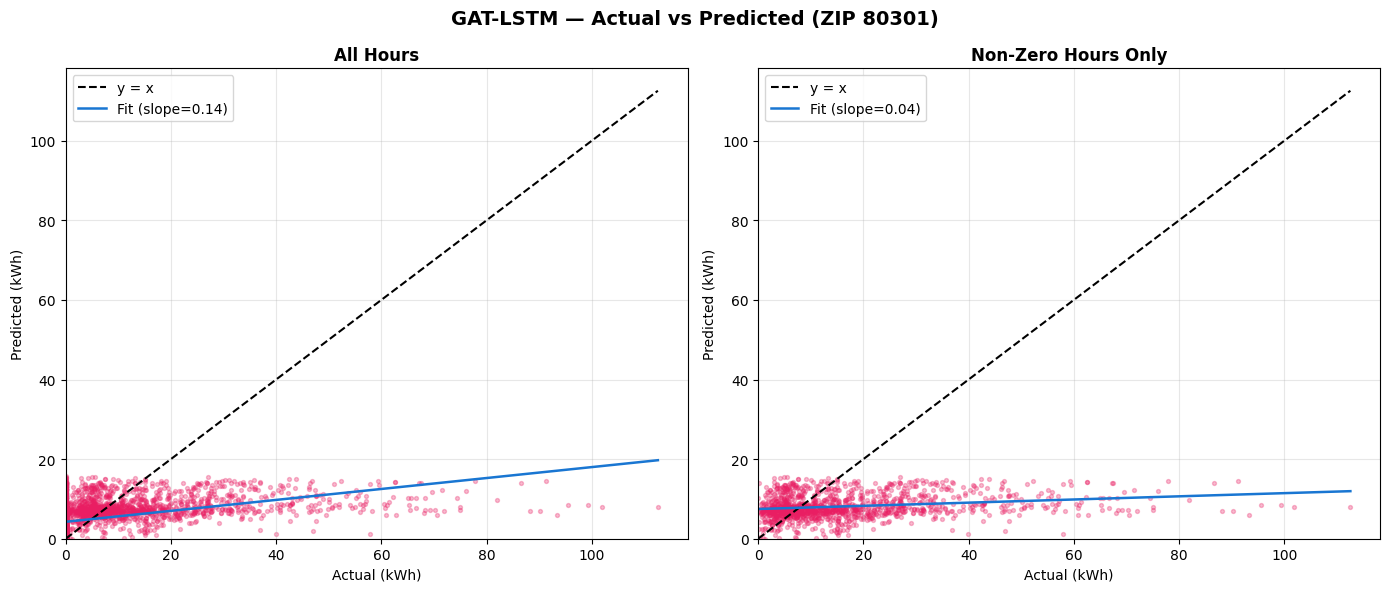

✅ Saved: gatlstm_scatter.png


In [44]:
# ============================================================
# SCATTER PLOT — NON-ZERO HOURS ONLY (GAT-LSTM, ZIP 80301)
# ============================================================
nz = yt_gat > 0
yt_nz = yt_gat[nz]
yp_nz = yp_gat[nz]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('GAT-LSTM — Actual vs Predicted (ZIP 80301)',
             fontsize=14, fontweight='bold')

# Left: All hours
ax = axes[0]
max_val = max(yt_gat.max(), yp_gat.max())
ax.scatter(yt_gat, yp_gat, alpha=0.3, s=8, color='#E91E63')
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.5, label='y = x')
m, b = np.polyfit(yt_gat, yp_gat, 1)
x_line = np.linspace(0, max_val, 200)
ax.plot(x_line, m*x_line+b, color='#1976D2', linewidth=1.8,
        label=f'Fit (slope={m:.2f})')
ax.set_title('All Hours', fontsize=12, fontweight='bold')
ax.set_xlabel('Actual (kWh)'); ax.set_ylabel('Predicted (kWh)')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(0, max_val*1.05); ax.set_ylim(0, max_val*1.05)

# Right: Non-zero hours only
ax = axes[1]
max_val_nz = max(yt_nz.max(), yp_nz.max())
ax.scatter(yt_nz, yp_nz, alpha=0.3, s=8, color='#E91E63')
ax.plot([0, max_val_nz], [0, max_val_nz], 'k--', linewidth=1.5, label='y = x')
m2, b2 = np.polyfit(yt_nz, yp_nz, 1)
x_line2 = np.linspace(0, max_val_nz, 200)
ax.plot(x_line2, m2*x_line2+b2, color='#1976D2', linewidth=1.8,
        label=f'Fit (slope={m2:.2f})')
ax.set_title('Non-Zero Hours Only', fontsize=12, fontweight='bold')
ax.set_xlabel('Actual (kWh)'); ax.set_ylabel('Predicted (kWh)')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(0, max_val_nz*1.05); ax.set_ylim(0, max_val_nz*1.05)

plt.tight_layout()
plt.savefig('gatlstm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: gatlstm_scatter.png")

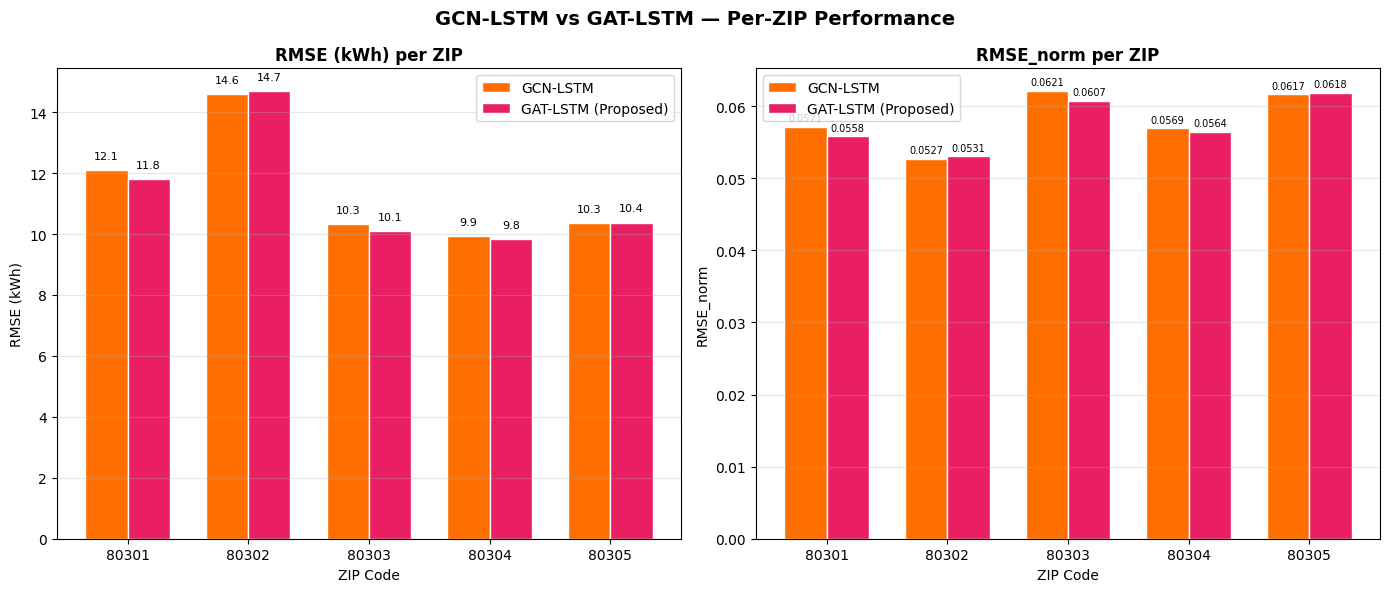

✅ Saved: per_zip_comparison.png


In [45]:
# ============================================================
# PER-ZIP BAR CHART — GCN-LSTM vs GAT-LSTM RMSE
# ============================================================
zip_labels = ['80301', '80302', '80303', '80304', '80305']

gcn_rmse_per_zip = [m['rmse'] for m in gcn_metrics]
gat_rmse_per_zip = [m['rmse'] for m in gat_metrics]

x      = np.arange(len(zip_labels))
width  = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('GCN-LSTM vs GAT-LSTM — Per-ZIP Performance',
             fontsize=14, fontweight='bold')

# Left: RMSE per ZIP
ax = axes[0]
bars1 = ax.bar(x - width/2, gcn_rmse_per_zip, width, label='GCN-LSTM',
               color='#FF6F00', edgecolor='white', linewidth=1.0)
bars2 = ax.bar(x + width/2, gat_rmse_per_zip, width, label='GAT-LSTM (Proposed)',
               color='#E91E63', edgecolor='white', linewidth=1.0)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

ax.set_title('RMSE (kWh) per ZIP', fontsize=12, fontweight='bold')
ax.set_xlabel('ZIP Code'); ax.set_ylabel('RMSE (kWh)')
ax.set_xticks(x); ax.set_xticklabels(zip_labels)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

# Right: RMSE_norm per ZIP
gcn_rn_per_zip = [m['rmse_norm'] for m in gcn_metrics]
gat_rn_per_zip = [m['rmse_norm'] for m in gat_metrics]

ax = axes[1]
bars3 = ax.bar(x - width/2, gcn_rn_per_zip, width, label='GCN-LSTM',
               color='#FF6F00', edgecolor='white', linewidth=1.0)
bars4 = ax.bar(x + width/2, gat_rn_per_zip, width, label='GAT-LSTM (Proposed)',
               color='#E91E63', edgecolor='white', linewidth=1.0)

for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7)
for bar in bars4:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7)

ax.set_title('RMSE_norm per ZIP', fontsize=12, fontweight='bold')
ax.set_xlabel('ZIP Code'); ax.set_ylabel('RMSE_norm')
ax.set_xticks(x); ax.set_xticklabels(zip_labels)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_zip_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: per_zip_comparison.png")

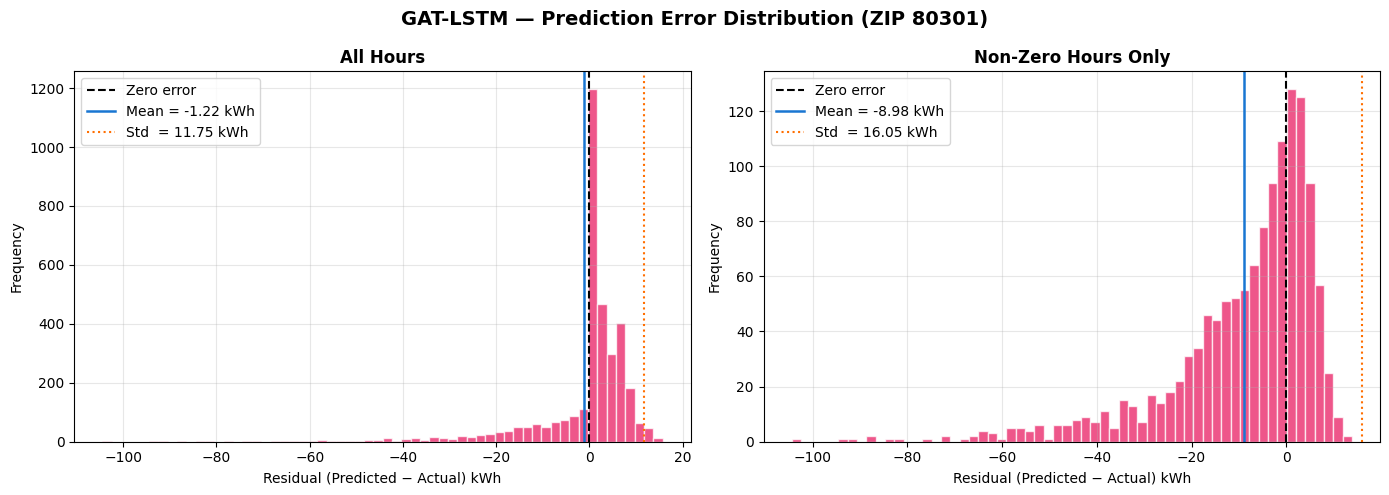

  All hours    — Mean residual: -1.2181 kWh  |  Std: 11.7542 kWh
  Non-zero hrs — Mean residual: -8.9757 kWh  |  Std: 16.0509 kWh
✅ Saved: gatlstm_residuals.png


In [46]:
# ============================================================
# RESIDUAL HISTOGRAM — GAT-LSTM (ZIP 80301)
# ============================================================
residuals    = yp_gat - yt_gat
residuals_nz = yp_gat[yt_gat > 0] - yt_gat[yt_gat > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GAT-LSTM — Prediction Error Distribution (ZIP 80301)',
             fontsize=14, fontweight='bold')

# Left: All hours
ax = axes[0]
ax.hist(residuals, bins=60, color='#E91E63', alpha=0.75, edgecolor='white')
ax.axvline(0,                    color='black', linestyle='--', linewidth=1.5, label='Zero error')
ax.axvline(residuals.mean(),     color='#1976D2', linestyle='-', linewidth=1.8,
           label=f'Mean = {residuals.mean():.2f} kWh')
ax.axvline(residuals.std(),      color='#FF6F00', linestyle=':', linewidth=1.5,
           label=f'Std  = {residuals.std():.2f} kWh')
ax.set_title('All Hours', fontsize=12, fontweight='bold')
ax.set_xlabel('Residual (Predicted − Actual) kWh')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: Non-zero hours only
ax = axes[1]
ax.hist(residuals_nz, bins=60, color='#E91E63', alpha=0.75, edgecolor='white')
ax.axvline(0,                       color='black', linestyle='--', linewidth=1.5, label='Zero error')
ax.axvline(residuals_nz.mean(),     color='#1976D2', linestyle='-', linewidth=1.8,
           label=f'Mean = {residuals_nz.mean():.2f} kWh')
ax.axvline(residuals_nz.std(),      color='#FF6F00', linestyle=':', linewidth=1.5,
           label=f'Std  = {residuals_nz.std():.2f} kWh')
ax.set_title('Non-Zero Hours Only', fontsize=12, fontweight='bold')
ax.set_xlabel('Residual (Predicted − Actual) kWh')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gatlstm_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  All hours    — Mean residual: {residuals.mean():.4f} kWh  |  Std: {residuals.std():.4f} kWh")
print(f"  Non-zero hrs — Mean residual: {residuals_nz.mean():.4f} kWh  |  Std: {residuals_nz.std():.4f} kWh")
print("✅ Saved: gatlstm_residuals.png")

  ZIP 80301 | All hrs  — Mean:   -1.22 kWh  Std: 11.75 kWh
  ZIP 80301 | Non-zero — Mean:   -8.98 kWh  Std: 16.05 kWh

  ZIP 80302 | All hrs  — Mean:    3.46 kWh  Std: 14.29 kWh
  ZIP 80302 | Non-zero — Mean:   -0.18 kWh  Std: 17.65 kWh

  ZIP 80303 | All hrs  — Mean:    0.64 kWh  Std: 10.07 kWh
  ZIP 80303 | Non-zero — Mean:   -4.41 kWh  Std: 13.06 kWh

  ZIP 80304 | All hrs  — Mean:    0.57 kWh  Std: 9.82 kWh
  ZIP 80304 | Non-zero — Mean:   -9.21 kWh  Std: 16.49 kWh

  ZIP 80305 | All hrs  — Mean:   -1.14 kWh  Std: 10.31 kWh
  ZIP 80305 | Non-zero — Mean:  -11.62 kWh  Std: 14.77 kWh



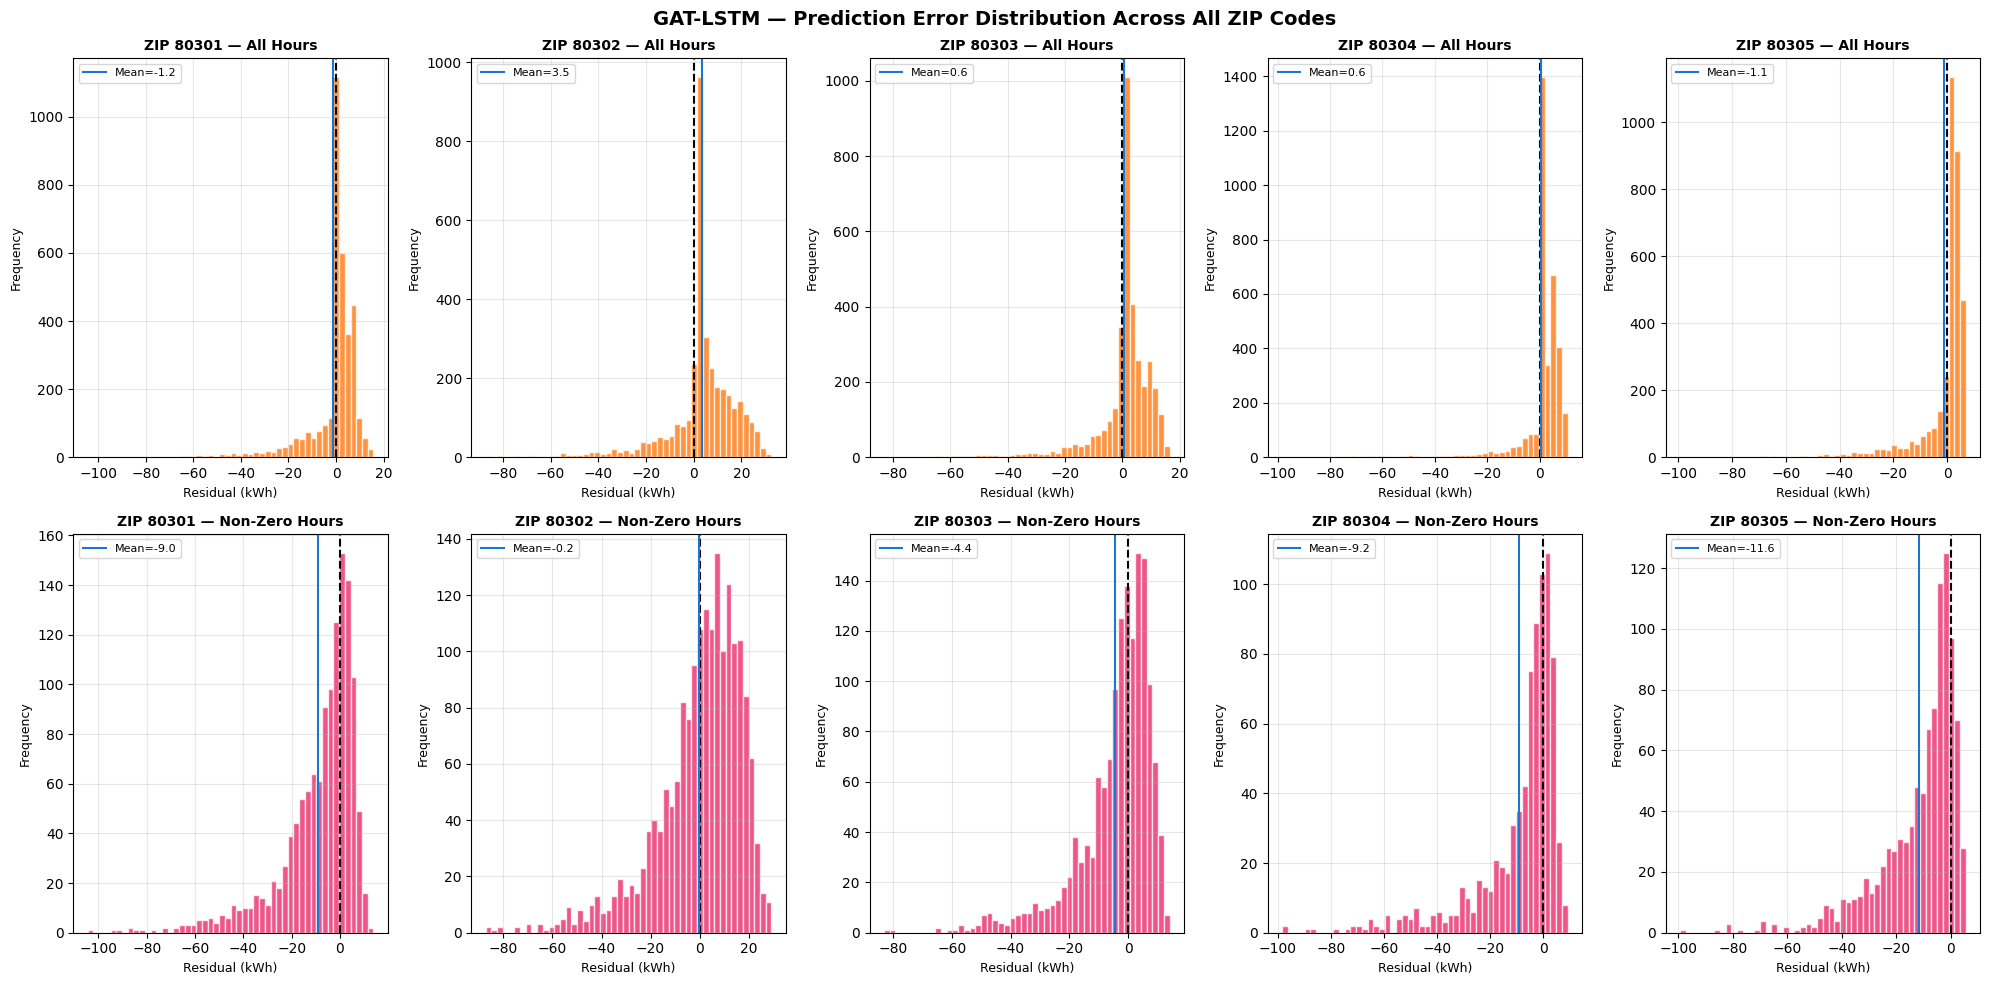

✅ Saved: gatlstm_residuals_all_zips.png


In [47]:
# ============================================================
# RESIDUAL HISTOGRAM — GAT-LSTM ALL 5 ZIP CODES
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('GAT-LSTM — Prediction Error Distribution Across All ZIP Codes',
             fontsize=14, fontweight='bold')

for i, zp in enumerate(zip_codes):
    yt_z = y_test_inv5_gat[:, i]
    yp_z = y_pred_inv5_gat[:, i]

    res_all = yp_z - yt_z
    nz_mask = yt_z > 0
    res_nz  = yp_z[nz_mask] - yt_z[nz_mask]

    # Top row: All hours
    ax = axes[0, i]
    ax.hist(res_all, bins=50, color='#FF6F00', alpha=0.75, edgecolor='white')
    ax.axvline(0,             color='black',   linestyle='--', linewidth=1.5)
    ax.axvline(res_all.mean(), color='#1976D2', linestyle='-',  linewidth=1.5,
               label=f'Mean={res_all.mean():.1f}')
    ax.set_title(f'ZIP {zp} — All Hours', fontsize=10, fontweight='bold')
    ax.set_xlabel('Residual (kWh)', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Bottom row: Non-zero hours
    ax = axes[1, i]
    ax.hist(res_nz, bins=50, color='#E91E63', alpha=0.75, edgecolor='white')
    ax.axvline(0,            color='black',   linestyle='--', linewidth=1.5)
    ax.axvline(res_nz.mean(), color='#1976D2', linestyle='-',  linewidth=1.5,
               label=f'Mean={res_nz.mean():.1f}')
    ax.set_title(f'ZIP {zp} — Non-Zero Hours', fontsize=10, fontweight='bold')
    ax.set_xlabel('Residual (kWh)', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    print(f"  ZIP {zp} | All hrs  — Mean: {res_all.mean():>7.2f} kWh  Std: {res_all.std():.2f} kWh")
    print(f"  ZIP {zp} | Non-zero — Mean: {res_nz.mean():>7.2f} kWh  Std: {res_nz.std():.2f} kWh")
    print()

plt.tight_layout()
plt.savefig('gatlstm_residuals_all_zips.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: gatlstm_residuals_all_zips.png")